# What makes people want a second date?

Tinder's marketing team is watching the number of matches go down. They want to know **what makes
people interested in each other** — and they have no way to answer that from the app itself, where
all they observe is a swipe with no reason attached.

So they fall back on an experiment. Between 2002 and 2004, Columbia University ran speed dating
events: every participant had a four-minute date with every other participant of the opposite sex,
rated them on six attributes, and secretly said yes or no to a second date. Around it, the
organisers collected questionnaires — what people said they were looking for, before, during and
after the evening.

The value of that dataset is exactly the gap it records: **what people say they want, next to what
they actually pick.**

---

### How this notebook is organised

| Section | What it does |
|---|---|
| 1 | Load the data and establish what one row actually is |
| 2 | Clean it: what is missing, what breaks the file's own rules, what we leave untouched |
| 3 | Describe it — distributions and correlations |
| 4 | Answer the five questions |
| 5 | What Tinder should take away from it |

Every chart is followed by what it says. Every cleaning decision is followed by its measured
effect.

## 1. Loading the data

The dataset and its official codebook (`Speed+Dating+Data+Key.doc`) both live in `data/`. The
codebook is the reference for every scale used below — several columns look numeric but are coded
categories, and several rating blocks use different scales in different waves.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
from pathlib import Path

# Show every column: the dataset has 195 of them and pandas truncates by default.
pd.set_option('display.max_columns', None)

# Plotly figures are rendered as static images rather than interactive widgets.
# Reason: this notebook is the deliverable and has to stay readable wherever it is opened.
# GitHub, nbviewer and PDF exports all strip interactive plotly output and would show nothing.
pio.renderers.default = 'png'

# Charts are also written to disk, so the README and the oral presentation can reuse them.
IMAGES = Path('images')
IMAGES.mkdir(exist_ok=True)

# --- Confidence intervals, used in questions 3, 4 and 5 -------------------------------------
# Several claims below are comparisons between numbers that came from a sample, so what they really
# compare is intervals. All three return the 95% interval and nothing else -- no p-value, because
# the question is always "how far apart are these two numbers", not "is this one exactly zero".

def ci_corr(r, n):
    """95% interval around a Pearson correlation, through Fisher's z transform."""
    z, se = np.arctanh(r), 1 / np.sqrt(n - 3)
    return np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)


def ci_mean(values):
    """95% interval around a mean."""
    values = pd.Series(values).dropna()
    half = 1.96 * values.std() / np.sqrt(len(values))
    return values.mean() - half, values.mean() + half


def ci_diff_rate(a, b):
    """95% interval around the difference between two yes-rates."""
    a, b = pd.Series(a).dropna(), pd.Series(b).dropna()
    se = np.sqrt(a.mean() * (1 - a.mean()) / len(a) + b.mean() * (1 - b.mean()) / len(b))
    return (a.mean() - b.mean()) - 1.96 * se, (a.mean() - b.mean()) + 1.96 * se


def show(fig, name, height=520):
    """Render a figure in the notebook and save it as a PNG under images/."""
    fig.update_layout(width=980, height=height, template='plotly_white',
                      margin=dict(t=70, b=60, l=70, r=40))
    fig.write_image(IMAGES / f'{name}.png', scale=2)
    fig.show()

In [2]:
df_source = pd.read_csv('data/Speed+Dating+Data.csv', encoding='ISO-8859-1')

# ISO-8859-1 and not UTF-8: the free-text fields (career, field of study, hometown) contain
# characters written on a 2004 Windows machine that are not valid UTF-8.

print(f'{df_source.shape[0]} rows x {df_source.shape[1]} columns')
df_source.head()

8378 rows x 195 columns


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,partner,pid,match,int_corr,samerace,age_o,race_o,pf_o_att,pf_o_sin,pf_o_int,pf_o_fun,pf_o_amb,pf_o_sha,dec_o,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o,like_o,prob_o,met_o,age,field,field_cd,undergra,mn_sat,tuition,race,imprace,imprelig,from,zipcode,income,goal,date,go_out,career,career_c,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,exphappy,expnum,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,attr4_1,sinc4_1,intel4_1,fun4_1,amb4_1,shar4_1,attr2_1,sinc2_1,intel2_1,fun2_1,amb2_1,shar2_1,attr3_1,sinc3_1,fun3_1,intel3_1,amb3_1,attr5_1,sinc5_1,intel5_1,fun5_1,amb5_1,dec,attr,sinc,intel,fun,amb,shar,like,prob,met,match_es,attr1_s,sinc1_s,intel1_s,fun1_s,amb1_s,shar1_s,attr3_s,sinc3_s,intel3_s,fun3_s,amb3_s,satis_2,length,numdat_2,attr7_2,sinc7_2,intel7_2,fun7_2,amb7_2,shar7_2,attr1_2,sinc1_2,intel1_2,fun1_2,amb1_2,shar1_2,attr4_2,sinc4_2,intel4_2,fun4_2,amb4_2,shar4_2,attr2_2,sinc2_2,intel2_2,fun2_2,amb2_2,shar2_2,attr3_2,sinc3_2,intel3_2,fun3_2,amb3_2,attr5_2,sinc5_2,intel5_2,fun5_2,amb5_2,you_call,them_cal,date_3,numdat_3,num_in_3,attr1_3,sinc1_3,intel1_3,fun1_3,amb1_3,shar1_3,attr7_3,sinc7_3,intel7_3,fun7_3,amb7_3,shar7_3,attr4_3,sinc4_3,intel4_3,fun4_3,amb4_3,shar4_3,attr2_3,sinc2_3,intel2_3,fun2_3,amb2_3,shar2_3,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,1,11.0,0,0.14,0,27.0,2.0,35.0,20.0,20.0,20.0,0.0,5.0,0,6.0,8.0,8.0,8.0,8.0,6.0,7.0,4.0,2.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,6.0,9.0,7.0,7.0,6.0,5.0,7.0,6.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,2,12.0,0,0.54,0,22.0,2.0,60.0,0.0,0.0,40.0,0.0,0.0,0,7.0,8.0,10.0,7.0,7.0,5.0,8.0,4.0,2.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,7.0,8.0,7.0,8.0,5.0,6.0,7.0,5.0,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,3,13.0,1,0.16,1,22.0,4.0,19.0,18.0,19.0,18.0,14.0,12.0,1,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,1.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,5.0,8.0,9.0,8.0,5.0,7.0,7.0,NaN,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,4,14.0,1,0.61,0,23.0,2.0,30.0,5.0,15.0,40.0,5.0,5.0,1,7.0,8.0,9.0,8.0,9

### What is one row?

This is the single most important thing to establish before averaging anything, and it is easy to
get wrong: **one row is one *directed* date, not one couple.**

Every one of those four-minute dates produces **two rows** — one written by each participant. Each
row is one-sided: it says *"this is how I rated my partner, and this is what I decided."* The cell
below checks that every date really does carry both of its rows, and the check is what makes the
claim more than an assumption.

A second property matters just as much: **waves were not the same size.** Depending on the evening,
a participant met between 5 and 22 people. Any statistic built on the *rank* of a date within the
evening has to account for that — we come back to it in **Question 5** (first date of the night, or last).

In [3]:
# --- One date produces two rows, one written by each participant -----------------------------
# If that is true, every ordered pair (participant, partner) has its mirror (partner, participant).

dates = df_source[['iid', 'pid']].dropna().astype(int)   # 10 rows have no partner id at all
pairs = set(zip(dates['iid'], dates['pid']))             # -> {(1, 11), (1, 12), ..., (11, 1), ...}

# A set rather than a list, because of the membership test on the next line: `x in set` is
# instant (hash lookup), `x in list` scans every element -- 8368 x 8368 comparisons instead
# of 8368. zip() pairs the two columns element by element, giving one tuple per date.
reciprocal = sum((partner, me) in pairs for me, partner in pairs)

# Each line is a check on the one above it, so the labels name their own subject rather than
# saying "of which": a row without a partner, a date entered twice, a row without its mirror.
print(f'rows in the file          : {len(df_source)}')
print(f'rows naming a partner     : {len(dates)}   ({len(df_source) - len(dates)} rows have no partner id)')
print(f'distinct (iid, pid) pairs : {len(pairs)}   (= no date recorded twice)')
print(f'pairs having their mirror : {reciprocal}   (= all of them)')

# --- The shape of the experiment ------------------------------------------------------------
dates_per_person = df_source.groupby('iid').size()
print(f'\nparticipants                 : {df_source["iid"].nunique()}')
print(f'waves                        : {df_source["wave"].nunique()}')
print(f'dates per participant        : {dates_per_person.min()} to {dates_per_person.max()}')
print(f'said yes on                  : {df_source["dec"].mean():.1%} of dates')
print(f'ended in a mutual match      : {df_source["match"].mean():.1%} of dates')
print(f'gender split (rows)          : {df_source["gender"].value_counts(normalize=True).round(3).to_dict()}')

rows in the file          : 8378
rows naming a partner     : 8368   (10 rows have no partner id)
distinct (iid, pid) pairs : 8368   (= no date recorded twice)
pairs having their mirror : 8368   (= all of them)

participants                 : 551
waves                        : 21
dates per participant        : 5 to 22
said yes on                  : 42.0% of dates
ended in a mutual match      : 16.5% of dates
gender split (rows)          : {1: 0.501, 0: 0.499}


Participants said yes on **42%** of their dates, but only **16.5%** of dates became a mutual match.
That gap is the whole business problem in one line: wanting someone is common, being wanted back at
the same moment is not.

## 2. Cleaning

The cleaning step is split in four. First we repair what the file got wrong on the way in — column types,
which have nothing to do with missing values. Then we look at where the gaps are and decide, family
of columns by family of columns, what to do about them. Then we check the answers against the scale
they were asked on. Finally we take a second look at the one column that was derived rather than
answered.

One rule governs every gap:

> Fill it only if a question below actually reads that column, **and** the value can be restored
> rather than invented.

Both halves matter. Filling a column no question reads is work that changes nothing. Filling one
that cannot be restored is worse than leaving it: a median dropped into a blank rating turns *"I had
no opinion"* into *"I thought they were average"*, and every correlation below inherits the
difference.

### 2.1 Two repairs to the way the file was read

In [4]:
df = df_source.copy()

# --- 1. Identifiers are labels, not quantities ----------------------------------------------
# iid, id and pid are numeric in the file, which means pandas will happily compute their mean.
# Casting them to string makes that impossible and keeps them out of any correlation matrix.
# The cast goes through Int64 (nullable integer) on purpose: pid is a float column, because
# 10 rows have no partner, so a direct astype(str) would write "11.0" where iid writes "11" --
# and every lookup of a partner by their id further down would silently match nothing.
for col in ['iid', 'id', 'pid']:
    df[col] = df[col].astype('Int64').astype(str)

# --- 2. income is a string ------------------------------------------------------------------
# It is stored as "69,487.00" with a thousands separator, so pandas reads the column as text.
df['income'] = df['income'].str.replace(',', '').astype(float)

### 2.2 Where the gaps are

Almost every column of this file has holes, so listing them one by one produces a page nobody reads
and no decision. What makes the list decidable is that **gaps come in families**: the columns of one
questionnaire block are blank on the same rows, for the same reason, and therefore deserve the same
verdict. The cell below counts the holes over the whole file, then groups the 75 columns this
analysis touches into the seven families that carry it.

In [5]:
# --- The whole file first: is this a few damaged columns, or the normal state of the file? ---
missing_rate = df.isna().mean()
print(f'{df.shape[1]} columns in total, of which {(missing_rate == 0).sum()} have no missing value '
      f'at all and {(missing_rate > 0).sum()} have at least one')

# --- Then the columns the analysis actually touches, grouped by what they ARE ----------------
# Inside a family the gaps share a cause, so they share a verdict. The families are the file's
# own structure: one questionnaire block each, plus the identifiers.
RATING    = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
INTERESTS = ['sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming',
             'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping',
             'yoga']
FAMILIES = {
    # Written after each date, about the partner: the six ratings given, the same six received
    # back from the partner (_o), and the overall liking score.
    'scorecard, after each date': RATING + [c + '_o' for c in RATING] + ['like'],
    # The same six preferences asked again halfway through the evening.
    'questionnaire, mid-event'  : [c + '1_s' for c in RATING],
    # Filled in before meeting anyone: demographics, the 17 interests, the 100-point budget
    # (*1_1) and the self-ratings (*3_1 -- five columns, there is no shar3_1).
    'sign-up form, before'      : ['age', 'race', 'imprace', 'imprelig', 'field_cd', 'goal',
                                   'date', 'go_out', 'career_c', 'exphappy'] + INTERESTS
                                  + [c + '1_1' for c in RATING]
                                  + [c + '3_1' for c in RATING if c != 'shar'],
    # Not asked of the participant at all: looked up afterwards from their zip code or their
    # undergraduate institution.
    'compiled from outside'     : ['income', 'mn_sat', 'tuition'],
    'expected no. of matches'   : ['expnum'],
    # The partner's age and race, copied onto our row.
    'the partner, echoed'       : ['age_o', 'race_o'],
    'identifiers and structure' : ['iid', 'id', 'pid', 'gender', 'wave', 'round', 'order',
                                   'position', 'samerace', 'int_corr', 'dec', 'match'],
}

inventory = pd.DataFrame([
    {'family'         : name,
     'columns'        : len(cols),
     'missing, lowest': f'{missing_rate[cols].min():.1%}',
     'highest'        : f'{missing_rate[cols].max():.1%}',
     'rows with a gap': df[cols].isna().any(axis=1).sum()}
    for name, cols in FAMILIES.items()]).set_index('family')
print(f'\nthe {sum(len(c) for c in FAMILIES.values())} columns this analysis touches:')
print(inventory.to_string())

# The sign-up family is the only one whose gaps are about *people* rather than about columns,
# so it gets one extra count: are these scattered blanks, or whole forms never filled in?
form = df.drop_duplicates('iid').set_index('iid')[FAMILIES['sign-up form, before']]
print(f"\nsign-up form: {form.isna().any(axis=1).sum()} participants left at least one blank, "
      f"of whom {form.isna().all(axis=1).sum()} never filled in any of it")

195 columns in total, of which 13 have no missing value at all and 182 have at least one

the 75 columns this analysis touches:
                            columns missing, lowest highest  rows with a gap
family                                                                      
scorecard, after each date       13            2.4%   12.8%             2371
questionnaire, mid-event          6           51.1%   51.1%             4282
sign-up form, before             38            0.8%    1.6%              246
compiled from outside             3           48.9%   62.6%             6459
expected no. of matches           1           78.5%   78.5%             6578
the partner, echoed               2            0.9%    1.2%              104
identifiers and structure        12            0.0%    1.9%              169

sign-up form: 19 participants left at least one blank, of whom 6 never filled in any of it


**Only 13 of the 195 columns are complete**, so gaps are the normal state of this file rather than
an accident, and the question is never *"can we fill this?"* but *"does anything below depend on
it?"*. Applied family by family, the rule settles all seven without a single value being imputed:

| family | verdict |
|---|---|
| **scorecard, after each date** | **Left as it is, deliberately.** Participants were told to leave a box blank if they had not formed an opinion, so a blank is an answer. A median would rewrite it as *"average"* — precisely the value that shifts a correlation the most. Every analysis below drops the rows it needs and says how many are left. |
| **questionnaire, mid-event** | **Not a gap at all.** It was run in only 12 of the 21 waves, so the 51% are people who were never asked. Question 1 therefore compares it to the sign-up answers on the *paired* participants only. |
| **sign-up form, before** | **Nothing to restore.** 19 participants left at least one blank, and 6 of them never filled in any of the form — they took part in the evening without registering. What is missing was never written down anywhere. |
| **compiled from outside** | **The one that would be dangerous to fill.** `income` is the median household income of the participant's zip code, empty when they came from abroad or gave no zip code; `mn_sat` and `tuition` come from a US college guide and are empty for anyone who studied outside the United States. All three are missing for a *systematic* reason, so a median would hand every foreign student the American average. |
| **expected no. of matches** | 78.5% missing, asked in a handful of waves — and no question below reads it. |
| **the partner, echoed** | `age_o` and `race_o` are missing on 104 rows, and no question below reads them either: the questions use `samerace`, not the two races it compares. |
| **identifiers and structure** | Complete where it counts — `dec`, `match`, `samerace`, `order`, `round`, `wave` and `gender` have no missing value at all, which is why every question can be asked on the full 8 378 rows before its own columns thin it out. |

So no value is imputed anywhere in this notebook. That is a result of the rule, not a shortcut around
it: on this file, every gap is either unusable or unused.

### 2.3 Are the answers on the scale they were asked on?

The codebook reproduces the questionnaires, so for every block of six attributes it states what the
respondent had to do: **split 100 points across them**, or **rate each one from 1 to 10**. It
changes that instruction from block to block, and inside one block from wave to wave — `*1_1`
below is asked both ways, one rule for waves 6-9 and another for the rest — and the file records the
answers without ever saying which instruction produced them. Hence the question this
section has to settle before any of them can be averaged: **were the rules imposed on the
participants respected?**

The file carries about twenty rating blocks. Auditing all of them would produce twenty paragraphs
and no decision, so the rule from section 2.2 applies here too — **a block is checked when a
question below reads it.** Six blocks pass that filter:

| block | what it is | the codebook asks to | read by |
|---|---|---|---|
| `attr` `sinc` `intel` `fun` `amb` `shar`, `like` | the scorecard, filled in after each four-minute date | 1 - 10 | Q2, Q3 |
| the same six, copied as `*_o` | what the **partner** wrote about us, copied onto our row | 1 - 10 | Q4 |
| `*3_1` | how the participant rates their own attributes | 1 - 10 | Q4 |
| the 17 interests, `sports` … `yoga` | how interested they are in each activity | 1 - 10 | Q3, through `int_corr` |
| `*1_1` | what they look for in a partner, at sign-up | **1 - 10** in waves 6-9, **split 100** in waves 1-5 and 10-21 | Q1, Q2 |
| `*1_s` | that same question again, halfway through the evening | 1 - 10 | Q1 |

**And the 90 columns left out, on purpose.** They are the *what do you think the opposite sex wants*
blocks (`*2_x`), the *what do your fellow men and women want* blocks (`*4_x`), the *how do you think
others see you* blocks (`*5_x`), the retrospective *what actually drove your decisions* blocks
(`*7_x`), and every block collected in the two follow-up surveys (`_2`, filled in the day after, and
`_3`, three weeks later). Not one question below reads a single one of them, so no state they could
be in would move an answer. **Question 5 reads no rating at all** — it is built on `dec`, `order`
and `round`.

In [6]:
# One row per participant: a questionnaire answer belongs to the PERSON and is copied onto each
# of their 5 to 22 date rows, so counting rows would count one answer up to 22 times over.
people = df.drop_duplicates('iid')

POINTS_1_1 = [c + '1_1' for c in RATING]                 # what you look for, at sign-up
POINTS_1_S = [c + '1_s' for c in RATING]                 # the same question, halfway through
SELF_3_1   = [c + '3_1' for c in RATING if c != 'shar']  # your own attributes; no shar3_1 exists
RECEIVED   = [c + '_o' for c in RATING]                  # the partner's scorecard, copied to our row


def block_total(cols, frame=None):
    """The six answers of one block added up, per participant. A block left blank stays blank."""
    frame = people if frame is None else frame
    return frame[cols].sum(axis=1, min_count=1)


def off_scale(frame, cols, low=1, high=10):
    """Every answer in `cols` that falls outside the scale it was asked on."""
    answers = frame[cols].stack().dropna()
    return answers[(answers < low) | (answers > high)]


# --- Five of the seven blocks are a 1-to-10 rating, and are checked value by value -----------
audit = []
for label, frame, cols in [('scorecard  attr..shar, like', df,     RATING + ['like']),
                           ('the same, copied as *_o',     df,     RECEIVED + ['like_o']),
                           ('*3_1  self-ratings',          people, SELF_3_1),
                           ('the 17 interests',            people, INTERESTS)]:
    broken = off_scale(frame, cols)
    audit.append({'block': label, 'the codebook asks to': '1 - 10',
                  'answers': len(frame[cols].stack().dropna()),
                  'answers breaking that rule': f'{len(broken)}, at {sorted(set(broken))}'
                                                if len(broken) else 'none'})

# --- The other two can only be checked on the six answers TOGETHER ---------------------------
# Six ratings out of 10 cannot add up to more than 60, so the total of the six is what tells a
# 1-to-10 block from a 100-point block. Everything below is read off the answers rather than
# copied from the codebook, which is what makes this a check and not a restatement.
# *1_1 is the one block the codebook asks for twice over: waves 6-9 rate each attribute 1 to 10,
# every other wave splits 100 points. So it is checked in two halves, one per rule, and only the
# half that was given a budget can be asked whether its budget adds up.
WAVES_1_10 = people['wave'].between(6, 9)

sign_up = block_total(POINTS_1_1).dropna()
budgets = sign_up[~WAVES_1_10.loc[sign_up.index]]
miscounted = int((budgets.sub(100).abs() >= 0.5).sum())
audit.append({'block': '*1_1  sign-up preference', 'the codebook asks to': '1 - 10 & split 100',
              'answers': len(sign_up),
              'answers breaking that rule': f'{miscounted} of the {len(budgets)} budgets are not 100'})

# *1_s carries no such exception -- the codebook asks every wave to rate 1 to 10.
mid_event = block_total(POINTS_1_S).dropna()
budget_at_mid = int((mid_event > 60).sum())
audit.append({'block': '*1_s  mid-event preference', 'the codebook asks to': '1 - 10',
              'answers': len(mid_event),
              'answers breaking that rule': f'{budget_at_mid} totals of 100, not 1-to-10'})

print('The six blocks the five questions read, against the rule the codebook states for each:\n')
print(pd.DataFrame(audit).to_string(index=False))


# --- Which instrument each wave really used, for the two blocks where it moves ----------------
def instrument_per_wave(cols):
    """Read the instrument off the answers themselves.

    A total near 45 is six ratings out of 10. A total of exactly 100 made of whole numbers is a
    budget really split by hand. A total of 100 made of two-decimal numbers is neither: it is a
    1-to-10 answer that somebody divided by its own total before the file was published.
    """
    answers  = people[cols]
    decimals = ((answers.round(0) != answers) & answers.notna()).any(axis=1)
    frame = pd.DataFrame({'wave': people['wave'], 'total': block_total(cols),
                          'decimals': decimals}).dropna(subset=['total'])
    table = frame.groupby('wave').agg(people=('total', 'size'), median_total=('total', 'median'),
                                      share_not_whole=('decimals', 'mean'))
    table['instrument really used'] = np.select(
        [table['median_total'] <= 60, table['share_not_whole'] > 0.5],
        ['rated 1 to 10', 'rated 1 to 10, then RESCALED to 100 in the file'],
        default='split 100 points by hand')
    return table.round(2)


for label, cols in [('*1_1, at sign-up', POINTS_1_1),
                    ('*1_s, halfway through the evening', POINTS_1_S)]:
    print(f'\n{label} — wave by wave:')
    print(instrument_per_wave(cols).to_string())

The six blocks the five questions read, against the rule the codebook states for each:

                      block the codebook asks to  answers        answers breaking that rule
scorecard  attr..shar, like               1 - 10    55502                     108, at [0.0]
    the same, copied as *_o               1 - 10    55433         110, at [0.0, 10.5, 11.0]
         *3_1  self-ratings               1 - 10     2710                              none
           the 17 interests               1 - 10     9248          20, at [0.0, 13.0, 14.0]
   *1_1  sign-up preference   1 - 10 & split 100      544 10 of the 443 budgets are not 100
 *1_s  mid-event preference               1 - 10      281    228 totals of 100, not 1-to-10

*1_1, at sign-up — wave by wave:
      people  median_total  share_not_whole                           instrument really used
wave                                                                                        
1         20         100.0             0.10     

**No — the rules are broken in four distinct places.** The table and the two wave-by-wave
breakdowns name them:

1. **108 zeros in the scorecard**, and the same 108 echoed in the `*_o` copy. Zero is not on a
   1-to-10 scale, and the scorecard explicitly told participants to leave the box blank when they
   had not formed an opinion — so a 0 is a value the instrument could not produce.
2. **Two ratings above 10**, `attr_o` at 10.5 and `fun_o` at 11 — and they appear *only* in the
   copied `*_o` columns, never in the scorecard those columns copy.
3. **20 interest ratings off the scale** — 0, 13 and 14 — spread over 14 participants.
4. **10 of the 443 participants given a budget did not make their 100 points add up to 100** at
   sign-up, with totals from 90 to 148.

And the wave tables add a fifth thing, which is not a participant breaking a rule but the
**instrument moving under the answers**:

* at sign-up, **waves 6 to 9 were asked to rate 1 to 10** — the codebook says so, and the column
  above is scored against that rule rather than against the budget. What the codebook does not say
  is that the file publishes their answers as **shares of 100**: two-decimal numbers adding up to
  exactly 100.00, which no hand-split budget does;
* halfway through the evening, the codebook asks everyone to rate 1 to 10, and 228 of the 281
  answers total 100 instead. They split two ways: **95 are waves 6 to 9 again**, rescaled here
  exactly as they were at sign-up, and **133 are waves 10, 11 and 15 to 17, who were handed a
  100-point budget** — whole numbers totalling 80 to 120, which no rescaling produces. Only **waves
  18 to 20 were asked the question the codebook actually describes.**

The first four cost almost nothing, and the cell below prices them rather than asserting it. The
fifth is the one that changes an answer.

In [7]:
# --- 1. The zeros: what happens to Question 2 if they are read as blanks instead of ratings --
zeros = df[RATING + ['like']] == 0
print(f'scorecard zeros : {int(zeros.sum().sum())} values over {int(zeros.any(axis=1).sum())} dates, '
      f'most of them on {zeros.sum().idxmax()} ({int(zeros.sum().max())})')

kept    = df.dropna(subset=RATING + ['dec'])
blanked = kept.replace({c: {0: np.nan} for c in RATING})
print('  correlation with the decision — zeros kept, then zeros read as blanks:')
for c in RATING:
    print(f'    {c:6s} {kept[c].corr(kept["dec"]):+.4f}  ->  {blanked[c].corr(blanked["dec"]):+.4f}')

# --- 2. The two ratings above 10. The *_o columns are a copy of the partner's scorecard, so the
# original is in the file and can be looked up instead of guessed at.
print('\nthe two ratings above 10, next to what the partner actually wrote:')
for copied, original in [('attr_o', 'attr'), ('fun_o', 'fun')]:
    for _, row in df[df[copied] > 10].iterrows():
        source = df[(df['iid'] == row['pid']) & (df['pid'] == row['iid'])][original].iloc[0]
        print(f'  {copied} = {row[copied]} on the date {row["iid"]}-{row["pid"]}, while participant '
              f'{row["pid"]} wrote {original} = {source:.0f} on their own row')

# --- 3. The interests, which reach Question 3 through int_corr ------------------------------
strays  = ((people[INTERESTS] < 1) | (people[INTERESTS] > 10)).any(axis=1)
touched = df['iid'].isin(people.loc[strays, 'iid']) | df['pid'].isin(people.loc[strays, 'iid'])
paired  = df.dropna(subset=['int_corr', 'dec'])
without = paired[~touched.loc[paired.index]]
print(f'\ninterests off the scale : {int(strays.sum())} participants, on one side or the other of '
      f'{int(touched.sum())} of the {len(df)} dates')
print(f'  corr(int_corr, dec) over every date     : {paired["int_corr"].corr(paired["dec"]):+.4f}'
      f'  (n={len(paired)})')
print(f'  corr(int_corr, dec) without those dates : {without["int_corr"].corr(without["dec"]):+.4f}'
      f'  (n={len(without)})')

scorecard zeros : 108 values over 72 dates, most of them on shar (59)
  correlation with the decision — zeros kept, then zeros read as blanks:
    attr   +0.4865  ->  +0.4864
    sinc   +0.2078  ->  +0.2083
    intel  +0.2145  ->  +0.2134
    fun    +0.4123  ->  +0.4123
    amb    +0.1849  ->  +0.1839
    shar   +0.4006  ->  +0.4027

the two ratings above 10, next to what the partner actually wrote:
  attr_o = 10.5 on the date 404-383, while participant 383 wrote attr = 10 on their own row
  fun_o = 11.0 on the date 436-440, while participant 440 wrote fun = 10 on their own row

interests off the scale : 14 participants, on one side or the other of 476 of the 8378 dates
  corr(int_corr, dec) over every date     : +0.0185  (n=8220)
  corr(int_corr, dec) without those dates : +0.0263  (n=7744)


**Three of the four cost nothing, and one is repairable outright.**

The **108 zeros** move no correlation Question 2 reads by more than **0.002**, whichever way they
are read. They stay as they are, with the caveat attached: a handful of what this file calls a
rating of zero is really *"I did not answer"*.

The **two values above 10** are the cleanest finding in this section. `attr_o = 10.5` sits on a date
whose partner wrote **10** on their own scorecard, and `fun_o = 11` likewise. The `*_o` columns are a
copy of the partner's scorecard — and a check of that copy over the whole file shows it is exact on
**every other value**, in both directions. So these two are transcription slips introduced by the
copy, the true answers are known, and Question 4 caps them back to 10 rather than dropping the two
participants.

The **20 stray interest ratings** are the only ones with a visible effect: `corr(int_corr, dec)`
moves from **+0.019** to **+0.026** when the 476 dates they touch are removed. That looks like a 40%
change and is really no change at all — Question 3 compares that number against **+0.40** for the
same concept measured on the scorecard, and +0.019 and +0.026 answer that comparison identically.
They stay, and Question 3 states the figure it uses.

The **10 miscounted budgets** need no repair either: the block is defined as a *share* of importance,
so dividing each answer by its own total is the transformation the question already calls for, and
Question 1 applies it to every answer it reads.

In [8]:
# Waves 6-9 were asked to rate 1 to 10 and the file shows shares of 100. If that is really what
# happened, the operation can be undone — and undoing it is a much stronger check than reading a
# median, because it either lands on whole numbers for every participant or it does not.
# WAVES_1_10 is the mask the audit above already built: the four waves the codebook rates 1 to 10.
RESCALED = WAVES_1_10


def undo_rescaling(row):
    """Recover the original 1-to-10 answers from six shares of 100.

    A share is 100 x rating / total, so multiplying the six shares by the right total turns them
    back into whole numbers. Every total a 1-to-10 answer could have had is tried, from 6 (six 1s)
    to 60 (six 10s), and the first one that makes all six whole again is the answer.
    """
    for total in range(6, 61):
        recovered = row.to_numpy(dtype=float) * total / 100
        if np.all(np.abs(recovered - recovered.round()) < 0.02):
            return pd.Series(recovered.round(), index=RATING)
    return pd.Series(np.nan, index=RATING)


converted = people.loc[RESCALED, POINTS_1_1].dropna()
recovered = converted.apply(undo_rescaling, axis=1)
print(f'{len(converted)} sign-up answers from waves 6-9, all of them shares of 100 in the file:')
print(f'  recovered as whole numbers : {int(recovered.notna().all(axis=1).sum())} of {len(converted)}')
print(f'  and every one lands between {recovered.min().min():.0f} and {recovered.max().max():.0f} '
      f'— the 1-to-10 scale the codebook asked those four waves for\n')

# --- What the rescaling costs: a share of 100 is not the same variable as 100 points split ---
shares = people[POINTS_1_1].div(block_total(POINTS_1_1), axis=0) * 100
spread = pd.DataFrame({
    label: sub.agg(['mean', 'std']).T.apply(lambda r: f"{r['mean']:5.1f}   (sd {r['std']:4.1f})",
                                            axis=1)
    for label, sub in [('rescaled from a 1-10 rating (waves 6-9)', shares[RESCALED]),
                       ('really split by hand (the 17 others)',    shares[~RESCALED])]})
spread.index = [c.replace('1_1', '') for c in POINTS_1_1]
print('Average share of the 100 points, by the instrument that produced it:')
print(spread.to_string())
print(f'\nparticipants putting 40 points or more on one single attribute : '
      f'{(shares[RESCALED].max(axis=1) >= 40).mean():.0%} of waves 6-9, '
      f'{(shares[~RESCALED].max(axis=1) >= 40).mean():.0%} of the others')

# --- And what it costs the answer to Question 1 ----------------------------------------------
gap = pd.DataFrame({
    label: sub[sub['gender'] == 1][POINTS_1_1].mean() - sub[sub['gender'] == 0][POINTS_1_1].mean()
    # No dropna(): each attribute is averaged over everyone who answered it, so the two columns
    # differ by the waves they include and by nothing else. That also makes the second column the
    # figure Question 1 publishes.
    for label, sub in [('all 21 waves',      shares.join(people['gender'])),
                       ('waves 6-9 removed', shares[~RESCALED].join(people['gender']))]})
gap.index = [c.replace('1_1', '') for c in POINTS_1_1]
print('\nQuestion 1 in one table — points men put on each attribute, minus the points women put:')
print(gap.round(1).to_string())

101 sign-up answers from waves 6-9, all of them shares of 100 in the file:
  recovered as whole numbers : 101 of 101
  and every one lands between 1 and 10 — the 1-to-10 scale the codebook asked those four waves for

Average share of the 100 points, by the instrument that produced it:
      rescaled from a 1-10 rating (waves 6-9) really split by hand (the 17 others)
attr                         16.2   (sd  3.5)                     24.2   (sd 13.9)
sinc                         18.0   (sd  2.7)                     17.1   (sd  7.9)
intel                        18.9   (sd  2.0)                     20.5   (sd  7.5)
fun                          17.9   (sd  2.4)                     17.3   (sd  6.8)
amb                          14.7   (sd  4.1)                      9.9   (sd  6.1)
shar                         14.4   (sd  3.9)                     11.2   (sd  6.8)

participants putting 40 points or more on one single attribute : 0% of waves 6-9, 18% of the others

Question 1 in one table — point

**The rescaling is proved, not suspected.** All 101 sign-up answers from waves 6 to 9 divide back
into whole numbers between 1 and 10 — a coincidence that does not happen 101 times in a row. Those
four waves did follow the rule they were given; it is the file that changed their answers
afterwards, and did so without leaving a column to say it.

**And that is not a change of scale, it is a change of variable.** The two columns of the middle
table answer the same question with the same six numbers, and they do not describe the same
behaviour. A budget forces a trade-off — to give attractiveness 40 points you have to take them off
the other five — and **18% of the participants who really split 100 points did exactly that**. A
1-to-10 rating forces nothing: you may call all six attributes an 8. Rescaled afterwards, those
answers pile up around 16.7 and **not one of the 101 can reach 40**, whatever the participant meant.
The standard deviation on attractiveness collapses from **13.9 to 3.5** and its mean falls from
**24.2 to 16.2**, for no reason any participant ever gave.

**So the answer to Question 1 depends on which waves are in it.** The gender gap on attractiveness
is **9.2 points over all 21 waves and 10.7 over the 17 that were really handed the budget** — the
101 rescaled answers, unable to be extreme, pull it down by a seventh. The direction survives, the
size does not.

---

**What this section decides.**

| finding | decision |
|---|---|
| 108 zeros in the scorecard | **kept.** Measured effect below 0.002 on every correlation Question 2 reads — with the caveat that a little of what this file calls a rating of zero is really *"I did not answer"*. |
| `attr_o` at 10.5, `fun_o` at 11 | **repaired by Question 4**, which caps them back to the 10 their partner actually wrote. |
| 20 stray interest ratings | **kept.** `int_corr` moves from +0.019 to +0.026 without them, and Question 3 weighs that number against +0.40, not against zero. |
| 10 budgets not adding up to 100 | **no action.** The block is a *share* of importance, so dividing each answer by its own total is the transformation the question already calls for. |
| `*1_1` rescaled in waves 6-9 | **dropped wherever the *level* of these points is read.** A share obtained by dividing a 1-to-10 answer by its own total is not a budget: nobody gave anything up to produce it, and by construction it cannot be extreme. Mixing the two is not adding noise to one variable, it is averaging two — so the bias does not shrink with sample size. The 101 answers therefore leave Question 1's chart and Question 2's declared column, and stay in Question 1's before/after. |
| `*1_s` on a budget in waves 10-11 and 15-17 | **harmless, and load-bearing.** Their `*1_1` is a budget too, so both moments sit on one ruler. They are 133 of the 227 participants Question 1's before/after keeps — the largest and cleanest of its three groups, despite being the only one that broke the codebook's rule. |
| `*1_s` on a 1-to-10 scale in waves 18-20 | **dropped from Question 1's before/after comparison.** For those 53 participants sign-up was a budget and mid-event was not. Nothing repairs it: the trade-off a budget imposes was never collected from them. |

The last three rows are the point of the section. **The same defect gets
opposite verdicts, and what decides is not how bad the defect is but what the question does with the
block:** read a *level* across two instruments and you are averaging two different variables, which no
sample size repairs; subtract one instrument from the other and you measure the instruments. Waves
6-9 fail the first test and pass the second, which is why they leave one half of Question 1 and stay
in the other.

### 2.4 One column that hides its gaps

`samerace` deserves a second look, because it was *derived* rather than answered — someone compared
the two participants' races and wrote 1 or 0 — and because that rule is exact enough to recompute. It
reports no missing value at all, yet we have just seen that `race` and `race_o` do have gaps. A
derived column cannot be more complete than what it derives from, so either it recovered something,
or it silently turned *"unknown"* into an answer.

In [9]:
# Does samerace say what it claims to say? Recompute it wherever both races are known.
both_known = df.dropna(subset=['race', 'race_o'])
agrees = ((both_known['race'] == both_known['race_o']).astype(int) == both_known['samerace']).sum()
print(f'samerace missing values : {df["samerace"].isna().sum()}')
print(f'rows where both races are known : {len(both_known)}, '
      f'of which samerace == (race == race_o) on {agrees}')

# And what does it say on the rows where one of the two races is unknown?
blind = df['race'].isna() | df['race_o'].isna()
print(f'\nrows where one of the two races is missing : {blind.sum()}')
print(f'  what samerace says there : {df.loc[blind, "samerace"].value_counts().to_dict()}')

# Those rows claim "different backgrounds" on no evidence. They cannot be repaired -- the race is
# missing on both sides of the file -- so the only question left is whether they matter. The
# column feeds question 3; here is that correlation computed with them and without them.
for label, frame in [('as given', df), ('dropping those rows', df[~blind])]:
    sub = frame.dropna(subset=['samerace', 'dec'])
    print(f'  corr(samerace, dec) {label:20s} : {sub["samerace"].corr(sub["dec"]):+.4f} '
          f'(n={len(sub)})')

samerace missing values : 0
rows where both races are known : 8242, of which samerace == (race == race_o) on 8242

rows where one of the two races is missing : 136
  what samerace says there : {0: 136}
  corr(samerace, dec) as given             : +0.0230 (n=8378)


  corr(samerace, dec) dropping those rows  : +0.0237 (n=8242)


**The column is trustworthy on the rows where it can be, and quietly wrong on the rest.** Wherever
both races are known it matches `race == race_o` on **every single row**, so it is exactly what the
codebook says it is. But on the **136** rows where one of the two races is missing it reports **0**
— *"different backgrounds"* — every time, never a blank. On those rows the honest answer is
*unknown*, and the file gives an answer instead.

It cannot be repaired: the missing race is missing on both sides of the file, so there is nothing to
compare. What is left is to measure whether it matters, and it does not — the correlation that
question 3 relies on moves from **+0.0230** to **+0.0237** when those rows are dropped. We keep
them, and we keep the caveat with them: **a small part of what this dataset calls "different
backgrounds" is really "we do not know"**.

## 3. Describing the data before questioning it

Two passes, in the order that makes each one interpretable: what the variables look like on their
own, then how they move together.

### 3.1 The six ratings, one attribute at a time

During the event, each participant rated their partner from 1 to 10 on six attributes. Averages
alone would hide the interesting part, so the chart shows the **whole distribution** and the table
gives the mean *and the variance* — an attribute everyone scores the same way cannot explain why
some dates end in a yes and others do not.

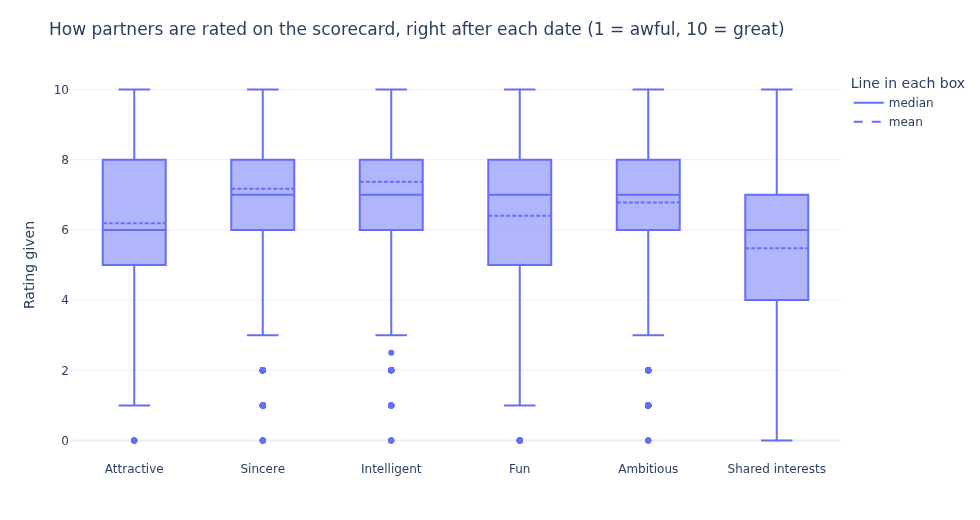

                  mean  median   var   count
Attractive        6.19     6.0  3.80  8176.0
Sincere           7.18     7.0  3.03  8101.0
Intelligent       7.37     7.0  2.40  8082.0
Fun               6.40     7.0  3.82  8028.0
Ambitious         6.78     7.0  3.22  7666.0
Shared interests  5.47     6.0  4.65  7311.0


In [10]:
SCORECARD = RATING          # the six ratings, named in section 2.2
LABELS = {'attr': 'Attractive', 'sinc': 'Sincere', 'intel': 'Intelligent',
          'fun': 'Fun', 'amb': 'Ambitious', 'shar': 'Shared interests'}

# Reshape to long format: one row per (date, attribute, score), which is what a box plot needs.
ratings_long = df.melt(value_vars=SCORECARD, var_name='attribute', value_name='score').dropna()
ratings_long['attribute'] = ratings_long['attribute'].map(LABELS)

fig = px.box(ratings_long, x='attribute', y='score',
             title='How partners are rated on the scorecard, right after each date (1 = awful, 10 = great)',
             labels={'attribute': '', 'score': 'Rating given'})

# A box plot draws the MEDIAN, so the solid line in each box does not match the mean in the table
# below -- boxmean adds the mean as a dashed line, and the gap between the two lines is the skew.
fig.update_traces(boxmean=True)

# Plotly puts no legend on those two lines, and an unlabelled dashed line is a question the reader
# should not have to ask. Two empty traces (x=[None]) draw nothing but appear in the legend, one
# per line style -- the colour is read from the boxes themselves rather than typed in again.
box_colour = fig.data[0].marker.color
for name, dash in [('median', 'solid'), ('mean', 'dash')]:
    fig.add_scatter(x=[None], y=[None], mode='lines', name=name,
                    line=dict(color=box_colour, dash=dash))
fig.update_layout(showlegend=True, legend=dict(title='Line in each box', y=1, x=1.01))

show(fig, '3_1_rating_distributions')

# Mean and variance side by side: the mean says how generous people are, the variance says how
# much they disagree -- and only the second can drive a decision. The median comes along because
# it is what the chart above draws: reading the two together is what shows the skew.
summary = df[SCORECARD].agg(['mean', 'median', 'var', 'count']).T
summary.index = summary.index.map(LABELS)
print(summary.round(2).to_string())

**The table as a whole.** Four of the six attributes have a median of 7 and the other two a median
of 6, and the six means span 5.47 to 7.37. The entire scorecard therefore sits in the top half of a
1-to-10 scale, on two median values out of ten — everything read below is a difference *inside*
that narrow, generous band.

**Reading it.** People are generous on the attributes that are hard to disprove in four minutes —
intelligence (7.4) and sincerity (7.2) — and much more reserved on the ones they feel qualified to
judge: shared interests (5.5) and attractiveness (6.2).

The variances point the same way. Intelligence has the *lowest* spread of the six: everybody scores
everybody around 7, so the column carries almost no information about who gets a yes. Shared
interests has the widest spread (4.65), with fun and attractiveness just behind (3.82 and 3.80).
Before running a single correlation, this already tells us which attributes *can* explain a
decision, and which are too uniform to explain anything.

### 3.2 Pearson correlation matrix

Now that we know what the variables look like, we can look at how they move together. The matrix
below covers **everything written on the scorecard** — the six ratings, the overall liking score,
and the yes/no decision — plus `match`, which the organisers derived from the two decisions rather
than anyone writing it down.

Two things to read in it, and the second is the one that shapes the rest of the notebook.

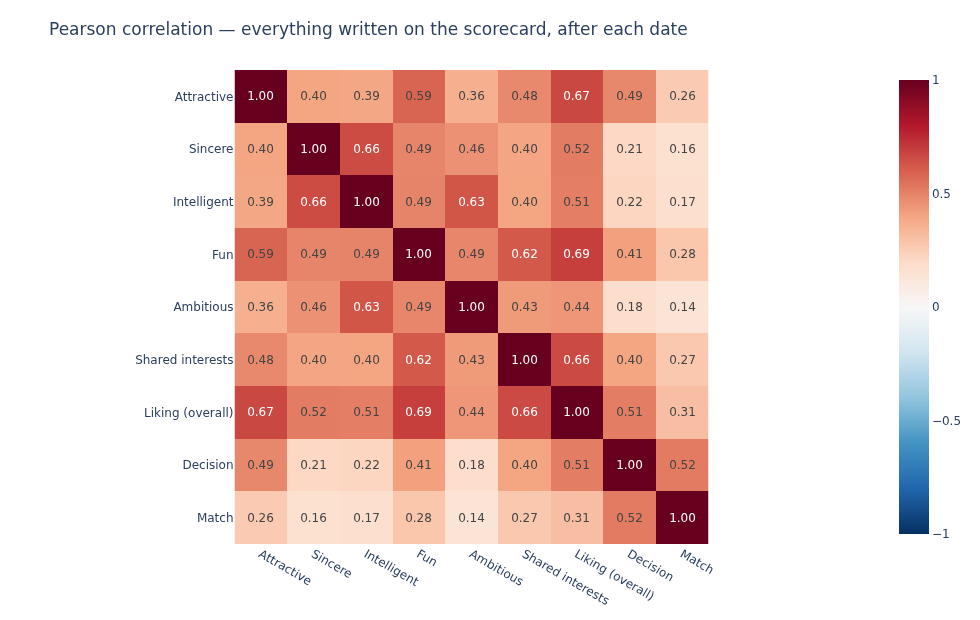

the six ratings, against each other : +0.36 (Attractive vs Ambitious) to +0.66 (Sincere vs Intelligent)
the six ratings, against liking     : +0.44 to +0.69


In [11]:
# Everything written on the scorecard, plus the outcome it produced.
scorecard_cols = SCORECARD + ['like', 'dec', 'match']
NAMES = {**LABELS, 'like': 'Liking (overall)', 'dec': 'Decision', 'match': 'Match'}

corr = df[scorecard_cols].corr(method='pearson')
corr.index = corr.columns = [NAMES[c] for c in scorecard_cols]

fig = px.imshow(corr, text_auto='.2f', color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
                title='Pearson correlation — everything written on the scorecard, after each date')
show(fig, '3_3_correlation_matrix', height=620)

# The two ranges quoted underneath, computed rather than eyeballed off the picture.
rated_names = list(LABELS.values())
block = corr.loc[rated_names, rated_names]
off_diag = block.where(~np.eye(len(rated_names), dtype=bool)).stack()

print(f'the six ratings, against each other : {off_diag.min():+.2f} '
      f'({" vs ".join(off_diag.idxmin())}) to {off_diag.max():+.2f} ({" vs ".join(off_diag.idxmax())})')
print(f'the six ratings, against liking     : {corr.loc[rated_names, "Liking (overall)"].min():+.2f} '
      f'to {corr.loc[rated_names, "Liking (overall)"].max():+.2f}')

**Reading it — two measured facts, then one name for them.**

1. **The six ratings all move together**, from +0.36 (attractiveness vs ambition) to +0.66
   (sincerity vs intelligence). Nobody rates a partner 9 on fun and 2 on sincerity.
2. **`like` moves with each of the six more tightly than they move with each other** (+0.44 to
   +0.69). `like` is a separate question — *"overall, how much do you like this person?"* — and the
   general impression tracks every detailed rating better than the details track one another.

That pattern is what psychologists call the **halo effect**: one overall impression bleeds into
every detailed judgement made in the same moment. And the moment is the point — all six boxes were
ticked on one scorecard, filled in immediately after the date, by someone who had already decided
whether they had enjoyed themselves. A participant who had a good time rates everything high,
including intelligence they had no way to assess in four minutes.

**Naming it is not proving it.** This matrix cannot rule out that attractive people genuinely are
funnier. **Question 3** (shared interests versus a shared background) tests it properly, by holding
`like` constant and measuring what survives.

**Either way, it is a constraint on what the rest of the notebook can claim.** Every column in this
matrix was recorded after the date, so a variable that predicts the decision well may be doing so
because it was written down in the same breath as the decision. Whenever a question can be answered
with something recorded *before* the event instead, that is the more trustworthy instrument — and
**Question 3** is built entirely on that distinction.

**Reading the decision column.** Attractiveness (+0.49), fun (+0.41) and shared interests (+0.40)
move with the decision. Sincerity (+0.21), intelligence (+0.22) and ambition (+0.18) barely do —
exactly the three attributes that section 3.1 showed everyone scores the same way.

---

# 4. The five questions

## Question 1 — What are the least desirable attributes in a partner? Does it differ by gender?

This asks what people *say* they want, so it uses the pre-event questionnaire: 100 points to
distribute across the six attributes, the more points the more important.

Three methodological points, each of which changes the numbers:

1. **The answer belongs to a participant, not to a date.** It is copied onto every row of that
   participant, so averaging over rows would give someone who had 22 dates four times the weight of
   someone who had 5. We deduplicate to one row per participant first.
2. **We rescale each participant to 100 points**, which repairs the handful of budgets found in
   section 2.3 that summed to 90, 110, 120 or 148, and turns blank blocks into missing values.
3. **We read this level on the 17 waves that were really handed the budget.** Section 2.3 showed
   that waves 6-9 were asked to rate each attribute 1 to 10 and that the file published those
   answers as shares of 100. A share built that way records no trade-off — nothing was given up to
   produce it — so averaging it with a real budget averages two different variables rather than one
   variable measured twice. The 101 answers concerned come back in the second half of this question,
   which subtracts the block from itself.

The event also asked the same question again halfway through the evening (`*1_s`). Section 2.3
established which waves used the same instrument at both moments, and the comparison below is run on
those — the others measured the change with one ruler and then another. Plotting the two shows
whether meeting real people changes what you claim to want.

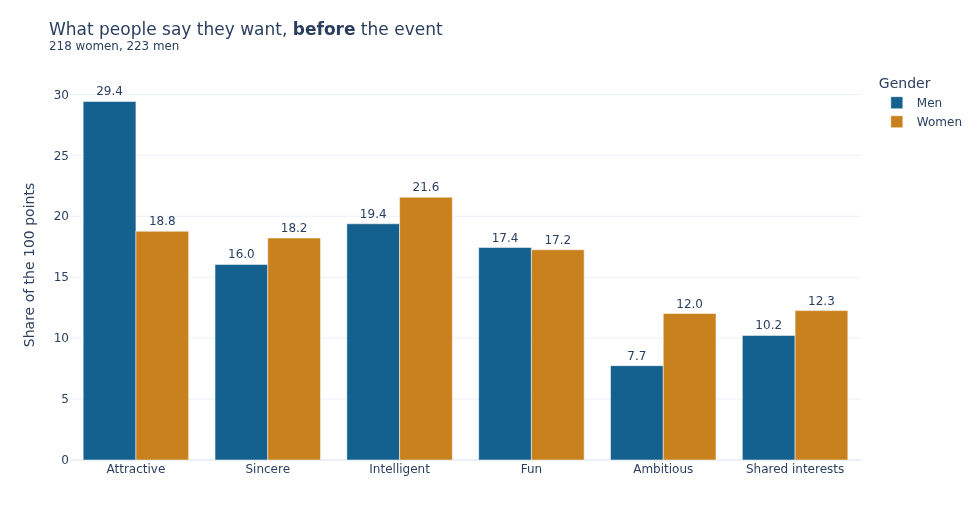

attribute  Attractive  Sincere  Intelligent   Fun  Ambitious  Shared interests
Gender                                                                        
Men              29.4     16.0         19.4  17.4        7.7              10.2
Women            18.8     18.2         21.6  17.2       12.0              12.3

449 of the 551 participants were really handed the 100 points.
attractiveness gap, men - women : 10.7 points


In [12]:
# One row per participant: their stated preferences are a property of the person.
people = df.drop_duplicates('iid').copy()

def as_shares(frame, cols):
    """Rescale each row of `cols` so it sums to 100, and return it as percentages.

    Legitimate here, and only here: the codebook defines these blocks as a budget to be split
    across the six attributes, so the share IS the quantity the question asks about. Rows that
    were left blank sum to 0 and become NaN, which is the correct outcome for "no answer".
    """
    total = frame[cols].sum(axis=1).replace(0, np.nan)
    return frame[cols].div(total, axis=0) * 100

people[POINTS_1_1] = as_shares(people, POINTS_1_1)
people[POINTS_1_S] = as_shares(people, POINTS_1_S)
people['Gender'] = people['gender'].map({0: 'Women', 1: 'Men'})

# Waves 6-9 rated each attribute 1 to 10 and the file turned that into shares of 100 (section 2.3).
# A share computed that way is not a budget: nobody gave anything up to produce it, and it cannot
# be extreme. Reading the LEVEL of these points therefore uses the waves that were really handed
# the budget -- and only the level. The before/after comparison below keeps all of them, because
# it subtracts the block from itself and both of its sides went through the same rescaling.
budgeted = people[~people['wave'].between(6, 9)]


def preference_chart(cols, title, filename, frame=None):
    frame = budgeted if frame is None else frame
    long = frame.melt(id_vars='Gender', value_vars=cols,
                       var_name='attribute', value_name='share').dropna()
    # 'attr1_1' -> 'attr' -> 'Attractive': strip the questionnaire suffix, keep the attribute.
    long['attribute'] = long['attribute'].str.split('1_').str[0].map(LABELS)

    n = long.groupby('Gender')['share'].count() // len(cols)

    # plotly express draws one bar per row and stacks them, so the mean has to be computed
    # here rather than left to the chart.
    means = long.groupby(['Gender', 'attribute'], as_index=False)['share'].mean()

    fig = px.bar(means, x='attribute', y='share', color='Gender', barmode='group', text='share',
                 category_orders={'attribute': list(LABELS.values())},
                 color_discrete_map={'Women': '#C8811C', 'Men': '#14618F'},
                 labels={'attribute': '', 'share': 'Share of the 100 points'},
                 title=f'{title}<br><sup>{n.get("Women", 0)} women, {n.get("Men", 0)} men</sup>')
    fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
    fig.update_yaxes(range=[0, 32])
    show(fig, filename)
    # reindex, because unstack() sorts the columns alphabetically while the chart above is
    # drawn in scorecard order -- the same six numbers must not be read in two orders.
    return (long.groupby(['Gender', 'attribute'])['share'].mean().unstack()
                .reindex(columns=list(LABELS.values())))

before = preference_chart(POINTS_1_1, 'What people say they want, <b>before</b> the event',
                          '4_1_declared_before')
print(before.round(1).to_string())

print(f"\n{len(budgeted)} of the {len(people)} participants were really handed the 100 points.")
print(f"attractiveness gap, men - women : {before.loc['Men', 'Attractive'] - before.loc['Women', 'Attractive']:.1f} points")

**The answer, read straight off the chart.** Both genders bury the same two attributes. Men put
their last two points on **ambition (7.7)** and **shared interests (10.2)**; women on **ambition
(12.0)** and **shared interests (12.3)** — three tenths of a point apart, so what women put last is
really the pair of them together.

**So does it differ by gender? At the bottom, barely. At the top, enormously.** The two genders
agree on what they do not want — the same two attributes, in the same order. What separates them is
**attractiveness: 29.4 points for men against 18.8 for women, more than ten points apart**, the
largest difference anywhere in the table and two and a half times the next one. Ambition is the mirror image
on a smaller scale: women give it 12.0 points, men 7.7. Everything else lands within three points.

That ten-point gap is the finding **Question 2** picks up and tests against what these same people
actually decided.

**Population and instrument.** One row per participant, so someone with 22 dates weighs the same as
someone with 5 — 218 women and 223 men, the figures the chart carries in its subtitle. They are the
449 participants of the 17 waves that were really given 100 points to split; the 101 answers from
waves 6-9 are out, for the reason given in section 2.3. Everything here is what people **declared
before meeting anyone**: a stated preference, not a behaviour.

227 participants across 9 waves were asked the same question at both moments:

                  Before the event  Halfway through  Change
Attractive                    21.3             23.1     1.8
Shared interests              12.4             13.1     0.7
Ambitious                     11.4             11.7     0.3
Sincere                       17.7             16.9    -0.8
Intelligent                   19.6             18.7    -0.9
Fun                           17.5             16.4    -1.1

The same two moments, split by gender:
                 Men (n=118)                Women (n=109)               
                      Before Halfway Change        Before Halfway Change
Attractive              25.1    27.0    1.9          17.1    18.8    1.7
Shared interests        11.6    11.9    0.4          13.3    14.4    1.1
Ambitious                9.5    10.2    0.7          13.4    13.4   -0.1
Sincere                 17.1    16.1   -1.1          18.4    17.9   -0.5
Intelligent            

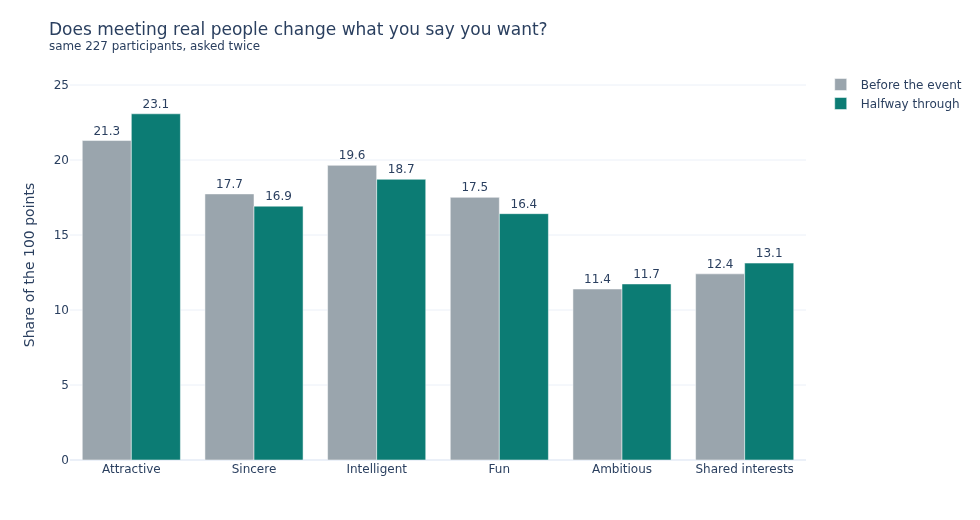

In [13]:
# Two filters, for two different reasons. First: the mid-event questionnaire was run in only 12 of
# the 21 waves, so a shift can only be read on the participants who answered *both* -- otherwise it
# compares two groups of people and calls the difference a change.
paired = people.dropna(subset=POINTS_1_1 + POINTS_1_S)

# Second: of those waves, three answered the mid-event block on a 1-10 scale while their sign-up
# block was a budget (section 2.3), so their two answers are not on one ruler. A wave is kept when
# its own median total lands on 100 -- read from the data rather than typed in as wave numbers.
# NB: `people` holds rescaled shares by this point, so the raw file is re-read here on purpose.
raw_people = df.drop_duplicates('iid')
wave_total = block_total(POINTS_1_S, frame=raw_people).groupby(raw_people['wave']).median()
same_instrument = wave_total[wave_total.round(0) == 100].index
comparable = paired[paired['wave'].isin(same_instrument)]

shift = pd.DataFrame({'Before the event': comparable[POINTS_1_1].mean().values,
                      'Halfway through':  comparable[POINTS_1_S].mean().values},
                     index=list(LABELS.values()))
shift['Change'] = shift['Halfway through'] - shift['Before the event']

print(f'{len(comparable)} participants across {comparable["wave"].nunique()} waves were asked the '
      f'same question at both moments:\n')
order = shift.sort_values('Change', ascending=False).index
print(shift.round(1).reindex(order).to_string())

# The same movement, split by gender, so that pooling is justified rather than assumed. Both
# moments are printed next to the change: a move of +1.9 means something different starting from
# 25 points than starting from 12, and the change alone hides where each gender started.
columns = {}
for code, name in [(1, 'Men'), (0, 'Women')]:
    who = comparable[comparable['gender'] == code]
    label = f'{name} (n={len(who)})'
    before_g, halfway_g = who[POINTS_1_1].mean().values, who[POINTS_1_S].mean().values
    columns[(label, 'Before')]  = before_g
    columns[(label, 'Halfway')] = halfway_g
    columns[(label, 'Change')]  = halfway_g - before_g

# Same order as the table above: the same six attributes must not be read in two orders.
by_gender = pd.DataFrame(columns, index=list(LABELS.values())).reindex(order)
print('\nThe same two moments, split by gender:')
print(by_gender.round(1).to_string())

plot = (shift[['Before the event', 'Halfway through']].reset_index(names='attribute')
        .melt(id_vars='attribute', var_name='moment', value_name='share'))
fig = px.bar(plot, x='attribute', y='share', color='moment', barmode='group',
             category_orders={'attribute': list(LABELS.values())},
             color_discrete_map={'Before the event': '#9AA5AD', 'Halfway through': '#0C7C74'},
             labels={'attribute': '', 'share': 'Share of the 100 points', 'moment': ''},
             text='share',
             title='Does meeting real people change what you say you want?'
                   f'<br><sup>same {len(comparable)} participants, asked twice</sup>')
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_yaxes(range=[0, 26])
show(fig, '4_1_declared_midway')

**Halfway through the evening, the declared budget moves — and it moves towards what can be seen.**
On the 227 participants asked the same question twice, **attractiveness gains 1.8 points** — the largest
move in the table — while fun loses 1.1 and intelligence 0.9. Nobody had been shown their
results, so this is what four minutes of practice does to an opinion formed in the abstract: the
criteria you cannot check in a conversation give way to the one you cannot miss.

**Both genders move the same way, on five attributes out of six.** Attractiveness gains 1.9 points
for men and 1.7 for women, fun loses 1.1 for both, intelligence and sincerity fall on both sides.
Only ambition splits them, and barely: +0.7 for men against −0.1 for women, the largest disagreement
anywhere in the table at 0.8 points. The pooled table above is therefore a fair summary rather than an average of two
different stories — which is worth stating, because **Question 2** is about to find a gap between
the genders that this one does not show.

## Question 2 — How important do people *think* attractiveness is, versus its real impact?

The two halves of this question are not measured on the same scale, and that is the whole
difficulty:

- **What people think** is a share of a 100-point budget (`attr1_1`).
- **The real impact** is how much an attribute moves the yes/no decision.

The instinct is to rescale one onto the other. It is the wrong move, for two reasons.

**A correlation is already scale-free.** Multiplying a rating by 1000 or shifting it by 7 leaves
`corr(attribute, decision)` unchanged — it always lives in [-1, 1]. There is nothing to normalise.

**And dividing each row by its own total is not a change of scale, it is a change of variable.**
It forces the six shares to sum to 100, so when attractiveness goes up the five others must
mechanically go down — a constraint that manufactures negative correlations out of arithmetic. Below,
the size of it.

The right comparison is therefore: **the declared budget, against the correlation computed on raw
ratings.**

In [14]:
rated = df.dropna(subset=SCORECARD + ['dec'])

# The artefact, measured rather than claimed: same data, with and without row normalisation.
shares = rated[SCORECARD].div(rated[SCORECARD].sum(axis=1), axis=0) * 100
artefact = pd.DataFrame({
    'corr on raw ratings':        {c: rated[c].corr(rated['dec']) for c in SCORECARD},
    'corr on row-normalised':     {c: shares[c].corr(rated['dec']) for c in SCORECARD},
})
artefact.index = artefact.index.map(LABELS)
print('Why we do not normalise the scorecard before correlating:')
print(artefact.round(3).to_string())
print('\n-> three of the six flip sign. The scorecard is a 1-10 rating, not a budget.')

Why we do not normalise the scorecard before correlating:
                  corr on raw ratings  corr on row-normalised
Attractive                      0.487                   0.249
Sincere                         0.208                  -0.223
Intelligent                     0.215                  -0.287
Fun                             0.412                   0.185
Ambitious                       0.185                  -0.209
Shared interests                0.401                   0.236

-> three of the six flip sign. The scorecard is a 1-10 rating, not a budget.


In [15]:
# Computed separately for each gender. Question 1 found a ten-point gap between men and women on
# attractiveness alone -- pooling them would average that away and hide the answer.
# `budgeted` and not `people`: the declared column is a level, so it follows the Question 1 rule
# and drops the 101 rescaled answers. The real-impact column keeps every wave -- it reads the
# scorecard, which is a 1-to-10 rating in all 21 of them.
def declared_vs_real(gender_code, gender_name):
    declared = budgeted[budgeted['gender'] == gender_code][POINTS_1_1].mean()
    declared.index = list(LABELS.values())

    sub = rated[rated['gender'] == gender_code]
    real = pd.Series({LABELS[c]: sub[c].corr(sub['dec']) for c in SCORECARD})

    table = pd.DataFrame({'Declared (points)': declared, 'Real impact (corr)': real})
    table['Rank declared'] = table['Declared (points)'].rank(ascending=False).astype(int)
    table['Rank real']     = table['Real impact (corr)'].rank(ascending=False).astype(int)
    table['Gap']           = table['Rank declared'] - table['Rank real']
    return table.assign(Gender=gender_name).sort_values('Rank real')

comparison = pd.concat([declared_vs_real(1, 'Men'), declared_vs_real(0, 'Women')])

for gender in ['Men', 'Women']:
    print(f'--- {gender} ---')
    print(comparison[comparison['Gender'] == gender]
          .drop(columns='Gender').round(3).to_string(), '\n')

--- Men ---
                  Declared (points)  Real impact (corr)  Rank declared  Rank real  Gap
Attractive                   29.418               0.517              1          1    0
Fun                          17.434               0.403              3          2    1
Shared interests             10.219               0.388              5          3    2
Ambitious                     7.741               0.214              6          4    2
Intelligent                  19.382               0.211              2          5   -3
Sincere                      16.043               0.187              4          6   -2 

--- Women ---
                  Declared (points)  Real impact (corr)  Rank declared  Rank real  Gap
Attractive                   18.768               0.443              2          1    1
Fun                          17.248               0.417              4          2    2
Shared interests             12.258               0.412              5          3    2
Intelligent    

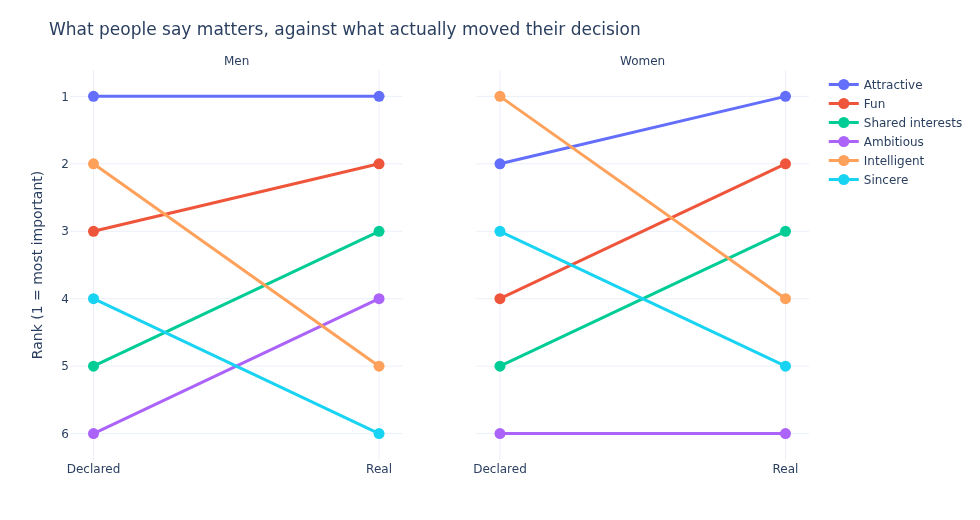

In [16]:
# Both columns are ranks on the same 1-6 scale, so a slope chart puts them on one axis:
# a line going down means the attribute matters less in practice than people claimed.
ranks = (comparison.reset_index(names='attribute')
         .melt(id_vars=['attribute', 'Gender'], value_vars=['Rank declared', 'Rank real'],
               var_name='measure', value_name='rank'))

ranks['measure'] = ranks['measure'].str.replace('Rank ', '').str.capitalize()

fig = px.line(ranks, x='measure', y='rank', color='attribute', facet_col='Gender', markers=True,
              facet_col_spacing=0.10,
              category_orders={'measure': ['Declared', 'Real'], 'Gender': ['Men', 'Women']},
              labels={'measure': '', 'rank': 'Rank (1 = most important)', 'attribute': ''},
              title='What people say matters, against what actually moved their decision')
fig.update_yaxes(autorange='reversed', dtick=1)
fig.update_traces(line_width=3, marker_size=11)
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
show(fig, '4_2_declared_vs_real')

**Men are honest about attractiveness. Women understate it.** Men rank it first out of six when
asked in the abstract, and it comes out first in their decisions — a gap of zero. Women rank it
**second** (18.8 points, behind intelligence) and it comes out **first** in theirs, and by the
widest margin of any attribute they rate (+0.44). The gap is one rank rather than three, but the
direction is unambiguous and the distance in points is not: women give intelligence 21.6 and
attractiveness 18.8, then decide on attractiveness. Splitting by gender is what makes this visible;
pooled together the two cancel out and the gap disappears entirely.

**Intelligence is the mirror image, for both.** Declared first by women and second by men, it lands
fourth and fifth in practice. Sincerity follows the same path. These are the socially respectable
answers — and section 3.1 already showed why they cannot work: everyone is rated around 7 on
intelligence, so the column has no room left to separate a yes from a no.

**Ambition is the one place the genders diverge again.** Men declare it last (7.7 points) and it
still lands fourth in their decisions — they use it more than they admit. Women declare it last too
(12.0 points) and it lands last: a gap of zero, and the only attribute on which they are exactly
right.

**The gap is not proof that people lie.** A four-minute date gives you very little to judge on:
attractiveness is available immediately, ambition is not. People may genuinely value intelligence
and be unable to act on it in the time given. What the data supports is the narrower statement:
**what people declare is a poor predictor of what they do**, whatever the reason.

## Question 3 — Are shared interests more important than a shared racial background?

The obvious way to answer is to correlate both with the decision. Doing that produces a clear
result — and the wrong one, because the two candidates are not the same kind of measurement:
`samerace` was recorded before the event, `shar` on the scorecard after the date.

### Three columns, and the difference between them is the whole question

Two of the three claim to measure the same thing — *do these two people have things in common?* —
and they disagree completely.

| | `shar` | `int_corr` | `samerace` |
|---|---|---|---|
| **What it is** | a rating from 1 to 10 | a correlation, −1 to +1 | 1 or 0 |
| **Who produced it** | the participant | the organisers, by calculation | the organisers, from two forms |
| **When** | on the scorecard, right after the date | at sign-up, before the event | at sign-up, before the event |
| **Built from** | the impression left by four minutes of conversation | seventeen activities each person rated 1-10 | the racial background each person declared |
| **The question behind it** | *"did this person share my interests?"* | *"do these two profiles look alike?"* | *"same background, yes or no?"* |
| **Same value both ways round?** | no — each of the two writes their own | yes, one number per pair | yes |

So `shar` is a **perception** and `int_corr` is a **fact**, about the same thing. `samerace` is a
different fact, and the one the question asks us to compare against.

The cell below measures how far apart the perception and the fact actually are, before we use
either of them.

In [17]:
# How much do the perception and the fact overlap? If shar were simply a noisy reading of
# int_corr, the two would move together. Two ways to check -- but first, what each column covers,
# because every count below is a subset of these.
paired_view = df.dropna(subset=['shar', 'int_corr'])
print(f'out of the {len(df)} rows in the file:')
for label, mask in [('shar',             df['shar'].notna()),
                    ('int_corr',         df['int_corr'].notna()),
                    ('samerace',         df['samerace'].notna()),
                    ('shar AND int_corr', df['shar'].notna() & df['int_corr'].notna())]:
    print(f'  {label:17s} {int(mask.sum()):5d}')

print(f'\n1. correlation between the two, over the {len(paired_view)} rows that carry both: '
      f'{paired_view["shar"].corr(paired_view["int_corr"]):+.3f}')


# Do the two people on the SAME date agree? int_corr is one number per pair by construction,
# so it must. shar is written twice, once by each of them, so it does not have to.
# Comparing two sides needs both of them, and each date sits in the file twice -- so the rows are
# filtered to those whose mirror carries the column too, then the mirrors are collapsed into one
# unordered pair each. Without that last step every date is counted twice.
def both_directions(column):
    sub = df.dropna(subset=['pid', column])
    values = sub.set_index(['iid', 'pid'])[column]
    mirrored = [(me, partner) for me, partner in values.index if (partner, me) in values.index]
    dates = {frozenset(pair) for pair in mirrored}
    agree = sum(1 for pair in dates for me, partner in [tuple(pair)]
                if abs(values[(me, partner)] - values[(partner, me)]) < 1e-9)
    return len(sub), len(mirrored), len(dates), agree


print('\n2. do the two people on the same date write the same value?')
print(f'     {"":9s} {"rows":>6s} {"mirrored":>9s} {"dates":>6s} {"agreeing":>9s}')
for column in ['int_corr', 'shar']:
    rows, mirrored, dates, agree = both_directions(column)
    print(f'     {column:9s} {rows:6d} {mirrored:9d} {dates:6d} {agree:9d}  ({agree / dates:.0%})')


out of the 8378 rows in the file:
  shar               7311
  int_corr           8220
  samerace           8378
  shar AND int_corr  7173

1. correlation between the two, over the 7173 rows that carry both: +0.051

2. do the two people on the same date write the same value?
                 rows  mirrored  dates  agreeing
     int_corr    8210      8210   4105      4105  (100%)
     shar        7302      6492   3246       514  (16%)


**The perception and the fact are all but unrelated: +0.05.** Knowing how similar two people's
declared interests really are tells you almost nothing about whether either of them will come away
feeling they had things in common.

**And the two people on the same date rarely agree about it.** `int_corr` is one number per pair by
construction, so both sides carry it identically — 100% by definition. `shar` is written twice, and
the two ratings match on only 16% of dates. The same four minutes, the same two people, two
different answers: `shar` describes the person holding the pen at least as much as the pair.

That is what makes the naive comparison unfair. `samerace` is a fact, fixed before anyone walked
into the room. `shar` sits on the scorecard, the same card, the same pen, the same minute as the
`dec` it would be compared to — and section 3.2 showed the whole card moves together.

`int_corr` is the way out: it measures the same idea as `shar`, but as a fact established in
advance, exactly like `samerace`. The codebook defines it as *"correlation between participant's
and partner's ratings of interests in Time 1"* — Time 1 being the sign-up survey, whose question 12
asks how interested you are in each of seventeen activities on a 1-10 scale: sports, museums,
reading, clubbing, yoga and so on.

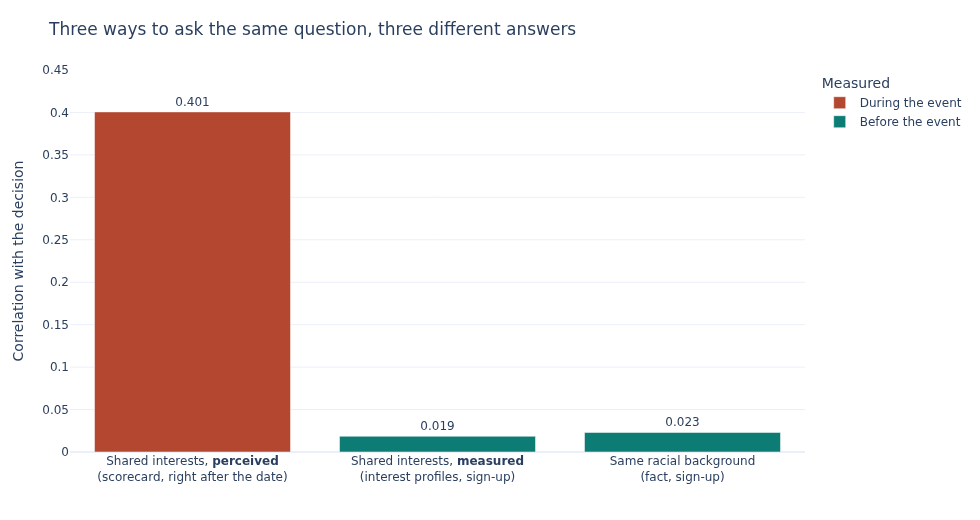

                                                    predictor  correlation     95% interval    n
Shared interests, perceived (scorecard, right after the date)        0.401 [+0.381, +0.420] 7311
      Shared interests, measured (interest profiles, sign-up)        0.019 [-0.003, +0.040] 8220
                       Same racial background (fact, sign-up)        0.023 [+0.002, +0.044] 8378


In [18]:
# The three candidate answers, side by side. What separates them is not the concept they measure
# -- two of them measure the same one -- but *when* they were written down.
predictors = {
    'shar':     'Shared interests, <b>perceived</b><br>(scorecard, right after the date)',
    'int_corr': 'Shared interests, <b>measured</b><br>(interest profiles, sign-up)',
    'samerace': 'Same racial background<br>(fact, sign-up)',
}

# Each predictor is taken on everyone who answered it, and comes with a 95% interval: the two
# pre-event facts are separated by 0.004, which means nothing until the width of the noise is
# printed next to it.
rows = []
for col, label in predictors.items():
    sub = df.dropna(subset=[col, 'dec'])
    r = sub[col].corr(sub['dec'])
    low, high = ci_corr(r, len(sub))
    rows.append({'predictor': label,
                 'correlation': r,
                 'when': 'During the event' if col == 'shar' else 'Before the event',
                 'n': len(sub),
                 '95% interval': f'[{low:+.3f}, {high:+.3f}]'})
strength = pd.DataFrame(rows)

fig = px.bar(strength, x='predictor', y='correlation', color='when', text='correlation',
             color_discrete_map={'During the event': '#B4472F', 'Before the event': '#0C7C74'},
             labels={'predictor': '', 'correlation': 'Correlation with the decision', 'when': 'Measured'},
             title='Three ways to ask the same question, three different answers')
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_yaxes(range=[0, 0.45])
show(fig, '4_3_interests_vs_race')

print(strength[['predictor', 'correlation', '95% interval', 'n']].assign(
    predictor=lambda d: d['predictor'].str.replace('<br>', ' ').str.replace(r'</?b>', '', regex=True)
).round(3).to_string(index=False))

**Compared naively, shared interests crush racial background — by a factor of seventeen** (+0.401
against +0.023). That is the answer most analyses of this dataset stop at.

**Compared fairly, neither is worth much — and the intervals say how little.** Put the two
*pre-event facts* next to each other: actually having interests in common scores **+0.019, with a
95% interval of [−0.003, +0.040] that contains zero**, while a shared racial background scores
**+0.023, interval [+0.002, +0.044]**, which just clears it. So the honest statement is not that
both are zero — it is that **the two intervals overlap almost entirely**, and that neither comes
anywhere near the +0.401 of the perceived version, whose interval [+0.381, +0.420] is nowhere near
either of them.

**So the answer depends on which measurement you accept, and that is the finding.** What predicts a
yes is not whether two people genuinely have things in common. It is whether one of them *came away
thinking so*. The perception is worth 0.40; the underlying fact is worth 0.02.

That distinction survives one obvious objection. Yes, some of the 0.40 is halo — you liked them, so
you ticked everything high. But the gap between 0.40 and 0.02 is far too large to be halo alone: if
perceived common ground were just a reflection of real common ground plus noise, the two numbers
could not be twenty times apart.

**And this is the actionable one for Tinder.** A racial background cannot be changed and, on this
evidence, should not be a matching signal — +0.023, an interval that barely clears zero, and no
practical weight at all. A declared interest list predicts even less. What predicts a second date is the feeling of connection that forms during
the conversation, which means the product lever is not better filtering upstream. It is whatever
helps two people *discover* common ground once they are talking.

### Does that hold once we account for how much people simply liked each other?

A fair objection to the paragraph above: `shar` might just be a proxy for the overall impression.
The check below compares the raw correlation with the **partial correlation**, holding the general
liking score (`like`) constant — that is, asking how much shared interests still explain *between
two dates the participant liked equally.*

In [19]:
def partial_corr(frame, x, y, control):
    """Correlation between x and y once `control` is removed from both.

    Each variable is regressed on the control, and we correlate what is left over. If shared
    interests only mattered through the general impression, the residuals would be uncorrelated.
    """
    sub = frame.dropna(subset=[x, y, control])
    residual = {}
    for col in (x, y):
        slope, intercept = np.polyfit(sub[control], sub[col], 1)
        residual[col] = sub[col] - (slope * sub[control] + intercept)
    return np.corrcoef(residual[x], residual[y])[0, 1], len(sub)

print(f'{"predictor":10s} {"raw corr":>10s} {"controlling for liking":>24s}')
for col in ['shar', 'int_corr', 'samerace']:
    sub = df.dropna(subset=[col, 'dec'])
    raw = sub[col].corr(sub['dec'])
    partial, n = partial_corr(df, col, 'dec', 'like')
    print(f'{col:10s} {raw:>+10.3f} {partial:>+24.3f}   (n={n})')

predictor    raw corr   controlling for liking
shar           +0.401                   +0.095   (n=7285)
int_corr       +0.019                   -0.002   (n=7996)
samerace       +0.023                   -0.000   (n=8138)


Holding the overall impression constant, perceived shared interests drop sharply — most of that
+0.40 really was the general feeling about the person, as the halo effect predicted. But it does not
drop to zero, and it stays above both pre-event facts, which barely move because they were never
entangled with the impression in the first place.

The conclusion holds, in a more careful form: **shared interests matter mainly as a component of
liking someone, not as an independent criterion — and the measured version, `int_corr`, does not
matter at all.**

## Question 4 — Can people accurately predict their own value on the dating market?

Before the event, participants rated themselves 1-10 on five attributes (`*3_1`, *"how do you think
you measure up?"*). During the event, their partners rated them on the same scale (`*_o`).

The comparison is therefore **self-assessment minus average rating received**, one number per
participant:

- **positive** → they thought better of themselves than their dates did
- **zero** → accurate
- **negative** → they underestimated themselves

Two precautions. The average received is computed per participant, so someone with 22 dates counts
once, like someone with 5. And the handful of out-of-range ratings found in section 2.3 are capped
at 10 before averaging.

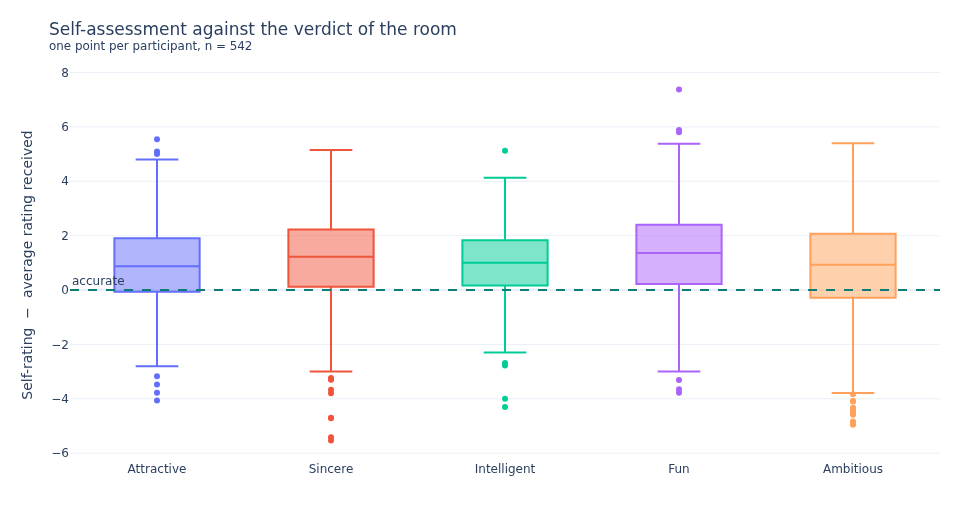

             mean  median   std  count  % above 0  % below 0    95% interval
Attractive   0.90    0.88  1.54  542.0      73.25      25.28  [+0.77, +1.03]
Sincere      1.07    1.22  1.58  542.0      76.75      21.40  [+0.93, +1.20]
Intelligent  0.99    1.00  1.23  542.0      79.70      19.19  [+0.88, +1.09]
Fun          1.27    1.36  1.59  542.0      79.15      19.19  [+1.14, +1.40]
Ambitious    0.76    0.93  1.83  542.0      69.19      28.41  [+0.60, +0.91]


In [20]:
SELF     = ['attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1']
RECEIVED = ['attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o']

judged = df.copy()
# Cap the two columns that exceeded the 1-10 ceiling (attr_o at 10.5, fun_o at 11).
judged[RECEIVED] = judged[RECEIVED].clip(upper=10)

# One row per participant: their own rating, and the mean of what their partners gave them.
self_view     = judged.groupby('iid')[SELF].first()
received_view = judged.groupby('iid')[RECEIVED].mean()

gap = pd.DataFrame(index=self_view.index)
for self_col, received_col in zip(SELF, RECEIVED):
    attribute = LABELS[self_col.replace('3_1', '')]
    gap[attribute] = self_view[self_col] - received_view[received_col]

gap_long = gap.melt(var_name='attribute', value_name='gap').dropna()

fig = px.box(gap_long, x='attribute', y='gap', color='attribute',
             labels={'attribute': '', 'gap': 'Self-rating  −  average rating received'},
             title='Self-assessment against the verdict of the room'
                   f'<br><sup>one point per participant, n = {gap.dropna(how="all").shape[0]}</sup>')
fig.add_hline(y=0, line_dash='dash', line_color='#0C7C74', line_width=2,
              annotation_text='accurate', annotation_position='top left')
fig.update_layout(showlegend=False)
show(fig, '4_4_self_assessment_gap')

# The share who overestimate belongs in the table, not in the commentary: a box plot shows where
# the middle of the distribution sits, it does not show what fraction of it is above zero.
summary = gap.agg(['mean', 'median', 'std', 'count']).T
summary['% above 0'] = (gap > 0).sum() / gap.notna().sum() * 100
summary['% below 0'] = (gap < 0).sum() / gap.notna().sum() * 100
# The bias is an average over 542 participants, so it comes with an interval. Printing it is what
# separates "they overestimate themselves" from "our sample happened to".
summary['95% interval'] = [f'[{low:+.2f}, {high:+.2f}]' for low, high
                           in (ci_mean(gap[c]) for c in gap.columns)]
print(summary.round(2).to_string())

**No — and the error goes in one direction, on every attribute.** All five boxes sit above the
accuracy line. The median participant rates themselves roughly **one point higher** than the room
does, on a 1-10 scale.

**The table is what carries the answer, not the box plot.** A box shows where the middle of a
distribution sits; it does not show what share of it is above zero, which is the actual question.
The `% above 0` column does: on attractiveness **73.2% of participants overestimate themselves**
against 25.3% who underestimate, and the pattern holds on all five attributes (69% to 80% above
the line).

**And the bias is not a sampling accident.** Each of the five gaps comes with a 95% interval, and
**none of them contains zero** — the narrowest, intelligence, runs [+0.88, +1.09]. On 542
participants, an average gap of zero is outside what this data supports, on every one of the five
attributes. It stays a statement about the average: the `% below 0` column shows that 19% to 28% of
participants underestimate themselves.

**The bias is strikingly uniform.** The mean gaps run from +0.76 (ambition) to +1.27 (fun) — a
range of half a point across five very different attributes. This is not a population that
misjudges specific traits; it is a population that is generally generous with itself.

It is tempting to expect the illusion to be largest on the attributes a stranger cannot verify in
four minutes. **The data does not support that.** Ambition is arguably the hardest of the five to
judge on a first date and it carries the *smallest* gap; fun is among the easiest and carries the
largest. Whatever drives the bias, it is not the availability of evidence.

**And the spread matters more than the average.** The standard deviations (1.2 to 1.8) are larger
than the bias itself, and the whiskers reach past ±4 points. The interesting population is not the
average participant who is off by one — it is the tails, who are wrong by four in both directions.

*A note on the measurement.* `*3_1` asks for the participant's own opinion of themselves. The
dataset also has `*5_1`, which asks the more literal question — *how do you think others perceive
you?* We use `*3_1` because 542 of 551 participants answered it, against 314 for `*5_1`.

## Question 5 — Is it better to be someone's first date of the night, or their last?

The tempting approach is to average the decision by `order` — the rank of the date within the
evening — and read the curve. It produces a clean downward slope that looks like fatigue setting in.

**That slope cannot be trusted, because `order` does not mean the same thing in every wave.**
Participants met between 5 and 22 people. So `order = 20` exists only in the longest evenings: the
left of the curve describes all 551 participants, the right describes a handful from one wave. Any
decline could be fatigue, or it could simply be that the people still present at rank 20 are a
different, pickier crowd. The two effects are impossible to separate.

The first cell measures how fast the population thins out.

In [21]:
timed = df.dropna(subset=['dec', 'order', 'round'])

coverage = timed.groupby('order').agg(mean_dec=('dec', 'mean'),
                                      participants=('iid', 'nunique'),
                                      waves=('wave', 'nunique'))
print(coverage.round(3).to_string())
print(f'\n-> order 1 covers all {coverage["participants"].iloc[0]} participants and '
      f'{coverage["waves"].iloc[0]} waves;')
print(f'   order {coverage.index[-1]} covers {coverage["participants"].iloc[-1]} participants '
      f'from {coverage["waves"].iloc[-1]} wave.')

       mean_dec  participants  waves
order                               
1         0.499           551     21
2         0.394           551     21
3         0.421           551     21
4         0.446           551     21
5         0.423           551     21
6         0.442           541     20
7         0.416           514     19
8         0.409           508     18
9         0.444           502     17
10        0.420           474     16
11        0.401           372     11
12        0.374           372     11
13        0.406           372     11
14        0.417           372     11
15        0.401           334      9
16        0.398           304      8
17        0.375           253      7
18        0.395           253      7
19        0.478           178      6
20        0.396           144      4
21        0.337            86      2
22        0.386            44      1

-> order 1 covers all 551 participants and 21 waves;
   order 22 covers 44 participants from 1 wave.


In [22]:
# The fix: relative position in the evening, so "80% of the way through" means the same
# thing whether the participant had 5 dates or 22. Every participant now contributes across
# the entire range instead of dropping out of it.
timed = timed.assign(relative_position=timed['order'] / timed['round'])

bins = np.arange(0, 1.01, 0.2)
binned = timed.groupby(pd.cut(timed['relative_position'], bins), observed=True).agg(
    yes_rate=('dec', 'mean'), participants=('iid', 'nunique'), waves=('wave', 'nunique'))
binned.index = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']

# Same three columns as the table below, deliberately: the two are meant to be read against each
# other, and identical headers are what makes that possible.
shown = [1, 5, 10, 15, 20, 22]
comparison = pd.DataFrame({
    'yes_rate':     coverage['mean_dec'].reindex(shown).values,
    'participants': coverage['participants'].reindex(shown).values,
    'waves':        coverage['waves'].reindex(shown).values,
}, index=[f'order {n}' for n in shown])

print('Yes-rate by RAW order — and how many people each point rests on:')
print(comparison.round(3).to_string())
print('\nYes-rate by RELATIVE position — every point rests on everybody:')
print(binned.round(3).to_string())
print(f'\nfor reference, the yes-rate over all {len(timed)} dates: {timed["dec"].mean():.1%}')

Yes-rate by RAW order — and how many people each point rests on:
          yes_rate  participants  waves
order 1      0.499           551     21
order 5      0.423           551     21
order 10     0.420           474     16
order 15     0.401           334      9
order 20     0.396           144      4
order 22     0.386            44      1

Yes-rate by RELATIVE position — every point rests on everybody:
         yes_rate  participants  waves
0-20%       0.440           551     21
20-40%      0.417           551     21
40-60%      0.430           551     21
60-80%      0.400           551     21
80-100%     0.415           551     21

for reference, the yes-rate over all 8378 dates: 42.0%


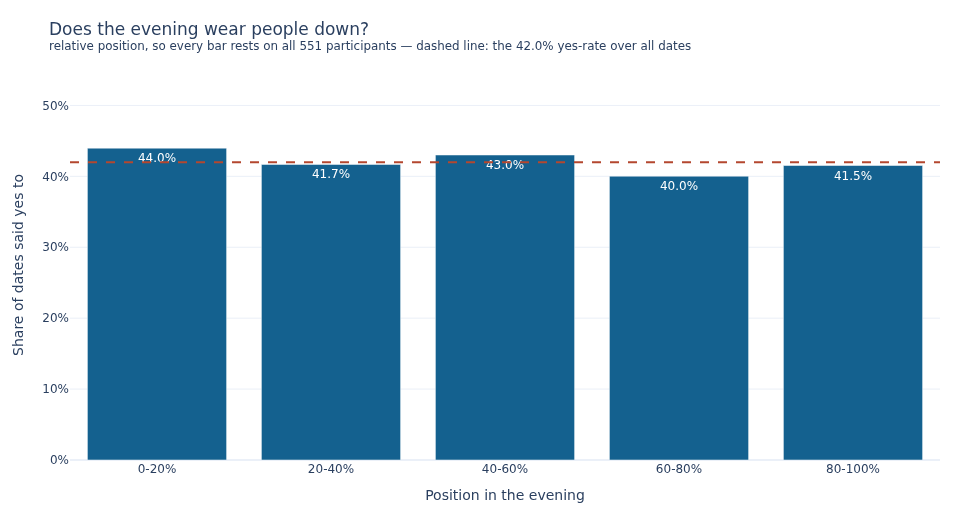

In [23]:
plot_data = binned.reset_index(names='position')

fig = px.bar(plot_data, x='position', y='yes_rate',
             text='yes_rate',
             labels={'position': 'Position in the evening', 'yes_rate': 'Share of dates said yes to'},
             title='Does the evening wear people down?'
                   f'<br><sup>relative position, so every bar rests on all 551 participants — '
                   f'dashed line: the {timed["dec"].mean():.1%} yes-rate over all dates</sup>')
fig.update_traces(texttemplate='%{text:.1%}', textposition='inside',
                  insidetextanchor='end', textfont_color='white', marker_color='#14618F')
fig.update_yaxes(tickformat='.0%', range=[0, 0.55])
fig.add_hline(y=timed['dec'].mean(), line_dash='dash', line_color='#B4472F', line_width=2)
show(fig, '4_5_relative_position')

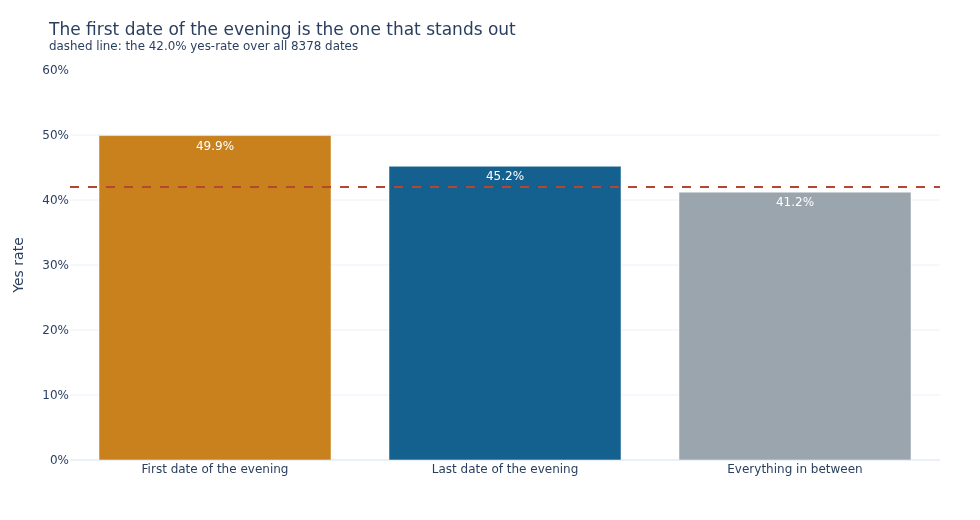

the middle of the evening, 7290 dates: 41.2% say yes

  first date  +8.7% vs the middle, 95% interval [+4.4%, +13.0%] — clears zero
  last date   +4.0% vs the middle, 95% interval [-0.3%, +8.3%] — CONTAINS ZERO

                 Position  Yes rate  vs the middle
First date of the evening      49.9            8.7
 Last date of the evening      45.2            4.0
    Everything in between      41.2            0.0


In [24]:
# The one comparison the wave-length problem does not affect: first against last, computed
# within each participant. Both dates belong to the same person and the same evening.
by_person = timed.sort_values(['iid', 'order']).groupby('iid')['dec']

# These three numbers are three independent rates -- "out of the dates in this position, what
# share got a yes" -- so they have no reason to add up to anything. Everything below is measured
# against ONE baseline, the middle of the evening, because that is the question: do the ends beat
# what lies between them? The overall yes-rate stays where it belongs, as the chart's dashed line.
middle  = timed[(timed['order'] > 1) & (timed['order'] < timed['round'])]['dec']
overall = timed['dec'].mean()

first_last = pd.DataFrame({
    'Position': ['First date of the evening', 'Last date of the evening', 'Everything in between'],
    'Yes rate': [by_person.first().mean(), by_person.last().mean(), middle.mean()],
})
first_last['vs the middle'] = first_last['Yes rate'] - middle.mean()

fig = px.bar(first_last, x='Position', y='Yes rate', color='Position', text='Yes rate',
             color_discrete_sequence=['#C8811C', '#14618F', '#9AA5AD'],
             title='The first date of the evening is the one that stands out'
                   f'<br><sup>dashed line: the {overall:.1%} yes-rate over all '
                   f'{len(timed)} dates</sup>')
fig.update_traces(texttemplate='%{text:.1%}', textposition='inside',
                  insidetextanchor='end', textfont_color='white')
fig.update_yaxes(tickformat='.0%', range=[0, 0.6])
fig.add_hline(y=overall, line_dash='dash', line_color='#B4472F', line_width=2)
fig.update_layout(showlegend=False, xaxis_title='')
show(fig, '4_5_first_vs_last')

# Each end against the middle, with an interval -- the two bars look alike on the chart and the
# intervals are what say whether they are alike.
print(f'the middle of the evening, {len(middle)} dates: {middle.mean():.1%} say yes\n')
for label, series in [('first date', by_person.first()), ('last date', by_person.last())]:
    low, high = ci_diff_rate(series, middle)
    verdict = 'clears zero' if low > 0 else 'CONTAINS ZERO'
    print(f'  {label:11s} {series.mean() - middle.mean():+.1%} vs the middle, '
          f'95% interval [{low:+.1%}, {high:+.1%}] — {verdict}')

print()
print(first_last.assign(**{'Yes rate': lambda d: (d['Yes rate'] * 100).round(1),
                           'vs the middle': lambda d: (d['vs the middle'] * 100).round(1)})
      .to_string(index=False))

**Corrected, the fatigue curve disappears.** On relative position the yes-rate goes 44.0%, 41.7%,
43.0%, 40.0%, 41.5% — a four-point spread with no trend. People are not gradually worn down by the
evening. The decline visible on raw `order` was largely the population changing underneath the
curve, not behaviour changing along it.

**The second chart cuts the same 8 378 dates a different way, and the two must not be read as one.**
Relative position splits every evening into five equal stretches; first-against-last keeps the two
extreme dates on their own and lumps the rest together. That is why the opening stretch reads 44.0%
while the first date alone reads 49.9%: **the 0-20% band holds 1 503 dates and only 551 of them are
first dates**, so the premium is diluted by the seconds and thirds sitting beside it. Each cut
answers a question the other cannot — the five bands ask whether the evening wears people down, the
three positions ask whether its very edges are judged differently.

**How to read the three numbers below.** They are not shares of one whole and do not add up to 100:
each is a separate rate — *of the dates held in this position, what fraction got a yes*. All three
are measured against one baseline, **the middle of the evening at 41.2%**, because that is what the
question asks: do the ends beat what lies between them? The 42.0% rate over all 8 378 dates stays on
the charts as a dashed line, and nowhere else.

**What survives is one end, not two.** The very first date gets a yes **49.9%** of the time and the
very last **45.2%**, against **41.2%** for everything in between — and the two intervals printed
above are what separate them:

| | vs the middle | 95% interval | |
|---|---|---|---|
| first date of the evening | **+8.7 points** | [+4.4, +13.0] | clears zero |
| last date of the evening | +4.0 points | [−0.3, +8.3] | **contains zero** |

So the answer to the question as asked is **first, clearly**. The last date sits above the middle by
four points, but on 551 participants that gap is indistinguishable from noise, and we do not claim
it.

**Which is why we stop short of naming a shape.** With both ends raised this would be a U — the ends
more memorable, the middle forgettable. With only the first end raised it is a first-date premium and
nothing more. The chart is consistent with the U, the numbers do not support it, and the honest
version is the narrower one: **being first helps, being last does not measurably hurt or help.**

**A plausible reading of the first-date premium is that it has no competition yet.** With nobody to
compare against, the participant has no scale and judges generously; the second date is already
measured against the first. That is a hypothesis this dataset is consistent with rather than one it
proves — the premium is clearly visible, but the experiment was not designed to isolate its cause,
and nothing here rules out the first partners simply having been more appealing.

**The practical consequence** for a product built on a queue of profiles is that position is not
neutral: the first profile shown is judged on different terms from the tenth.

---

# 5. What Tinder should take from this

### The four findings

**1. What people declare is a poor guide to what they choose — and women more than men.** Men
declare attractiveness first and use it first: no gap. Women declare it *second*, behind
intelligence and by three points, and it then drives their decisions more strongly than any other
attribute. Intelligence makes the opposite trip for both genders, from the top of the declared list
to fourth or fifth in practice.
*A stated-preference questionnaire is not a reliable input to a matching algorithm.*

**2. Perceived common ground predicts a second date. Actual common ground does not.** Interests
genuinely shared, measured before anyone met, correlate +0.019 with a yes, 95% interval
[−0.003, +0.040]. Sharing a racial background scores +0.023, interval [+0.002, +0.044] — the two
intervals overlap almost entirely, so neither can be called the stronger. Interests *felt* to be shared during the conversation correlate +0.401, interval
[+0.381, +0.420], which overlaps neither. *The lever is not
better filtering upstream, it is helping two people find common ground while they talk.*

**3. Nobody knows what they are worth.** Participants rate themselves about a point above what the
room gives them, on every attribute, and 73% overestimate their own attractiveness. The bias is
uniform rather than concentrated on any particular trait, and the individual spread is larger than
the bias itself. *Self-declared profile attributes should be treated as aspiration, not measurement.*

**4. Position in the queue is not neutral — the first slot, specifically.** The first date of the
evening gets a yes 49.9% of the time against 41.2% in between, a gap of +8.7 points whose 95%
interval [+4.4, +13.0] is comfortably clear of zero. The last date sits at 45.2%, but its +4.0
points carry an interval of [−0.3, +8.3] and we do not count it. Once relative position is used
instead of raw rank the apparent fatigue slope disappears entirely. *The first profile a user sees
is judged on different terms from the tenth; the rest of the queue looks flat.*

### What follows for the product

- **Stop weighting declared preferences.** They describe the person users believe they are looking
  for, and finding 1 shows that portrait and the actual decision barely overlap. What people do is
  the better signal — and on this data, *doing* meant a yes after four minutes, not a swipe.
- **Invest in the conversation, not the filter.** Finding 2 is the strongest result in this
  notebook and it points away from matching criteria and toward the first exchange — prompts,
  icebreakers, anything that surfaces common ground rather than asserting it in advance.
- **Do not treat racial background as a matching signal.** It predicts a second date no better than
  chance — an obvious fairness cost for no measured benefit.
- **Treat queue position as a variable, not a detail.** If the first profile is judged generously,
  ordering is a product decision with measurable consequences, and it should be tested as one.

### What this data cannot tell us

Worth saying out loud before any of it reaches a roadmap:

- **It is twenty years old**, collected from Columbia graduate students between 2002 and 2004. That
  is not Tinder's user base in age, geography or background.
- **Four minutes face to face is not a swipe.** Everything here is measured after a conversation;
  Tinder's decision happens before one. Findings 1 and 3 transfer reasonably well because they are
  about self-knowledge. Findings 2 and 4 are about the encounter itself and transfer less directly.
- **Correlation, not causation.** Nothing here was randomised except the pairing.